In [1]:
import os 
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.read_csv('combined_metrics.csv')



In [2]:
metric_map = {'object': 'clip_acc', 'art': 'clip_score', 'celebrity': 'GCD'}
metric_str = {'clip_acc': 'CLIP Accuracy', 'clip_score': 'CLIP Score', 'GCD': 'GCD Accuracy', 'FID': 'FID Score'}
x_axis_labels = {
    'erase_ship': 'Erase Ship',
    'erase_bird': 'Erase Bird',
    'erase_automobile': 'Erase Automobile',
    'erase_object_5': 'Erase 5 Objects',
    'erase_cele_1': 'Erase 1 Celeb',
    'erase_cele_5': 'Erase 5 Celebs',
    'erase_cele_10': 'Erase 10 Celebs',
    'erase_cele_100': 'Erase 100 Celebs',
    'erase_art_100': 'Erase 100 Artists'
}

The following groups have an incorrect number of values:
Group ('erase_ship', 'before fine-tuning') has 4 values:
     algo    change    task      config finetune_algo finetune_task  \
102  MACE  baseline  object  erase_ship          none          none   
126  MACE  baseline  object  erase_ship          none          none   
150  MACE  baseline  object  erase_ship          none          none   
153  MACE  baseline  object  erase_ship          none          none   

    finetune_prompts           prompts_csv seed    type    metric  value  \
102             none  object_ship_concepts    1  erased  clip_acc  0.105   
126             none  object_ship_concepts    2  erased  clip_acc  0.105   
150             none  object_ship_concepts    0  erased  clip_acc  0.060   
153             none  object_ship_concepts    0  erased  clip_acc  0.065   

                  phase  
102  before fine-tuning  
126  before fine-tuning  
150  before fine-tuning  
153  before fine-tuning  


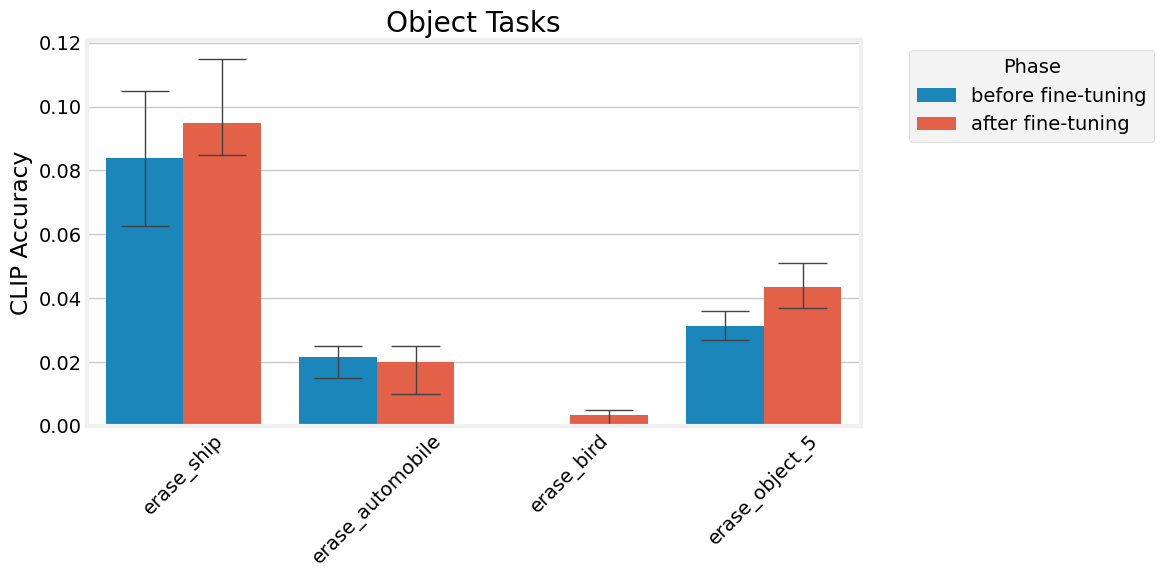

Figure saved as 'figures/warmup/object_warmup_impact.png'
The following groups have an incorrect number of values:
Group ('erase_art_100', 'after fine-tuning') has 4 values:
    algo    change task         config finetune_algo finetune_task  \
49  MACE  baseline  art  erase_art_100          lora           art   
65  MACE  baseline  art  erase_art_100          lora           art   
80  MACE  baseline  art  erase_art_100          lora           art   
82  MACE  baseline  art  erase_art_100          lora           art   

             finetune_prompts       prompts_csv seed    type      metric  \
49  art_random_concepts_seed0  art_100_concepts    1  erased  clip_score   
65  art_random_concepts_seed0  art_100_concepts    2  erased  clip_score   
80  art_random_concepts_seed0  art_100_concepts    0  erased  clip_score   
82  art_random_concepts_seed0  art_100_concepts    0  erased  clip_score   

      value              phase  
49  21.6982  after fine-tuning  
65  21.6903  after fine-tuni

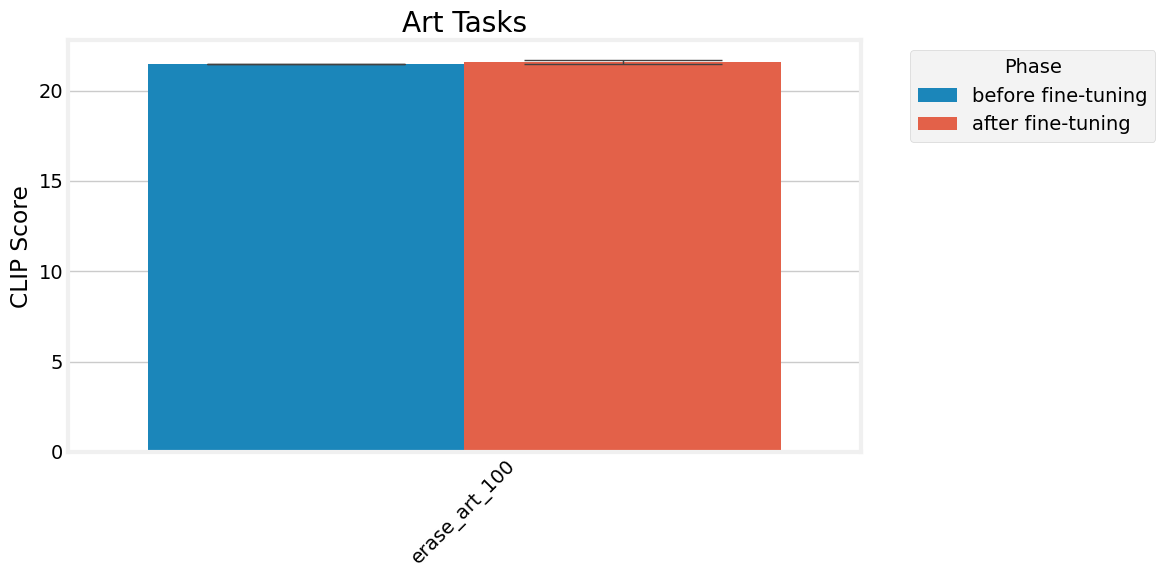

Figure saved as 'figures/warmup/art_warmup_impact.png'
The following groups have an incorrect number of values:
Group ('erase_cele_1', 'before fine-tuning') has 4 values:
     algo    change       task        config finetune_algo finetune_task  \
177  MACE  baseline  celebrity  erase_cele_1          none          none   
180  MACE  baseline  celebrity  erase_cele_1          none          none   
184  MACE  baseline  celebrity  erase_cele_1          none          none   
185  MACE  baseline  celebrity  erase_cele_1          none          none   

    finetune_prompts           prompts_csv seed    type metric  value  \
177             none  celebrity_1_concepts    1  erased    GCD    0.0   
180             none  celebrity_1_concepts    2  erased    GCD    0.0   
184             none  celebrity_1_concepts    0  erased    GCD    0.0   
185             none  celebrity_1_concepts    0  erased    GCD    0.0   

                  phase  
177  before fine-tuning  
180  before fine-tuning  
184 

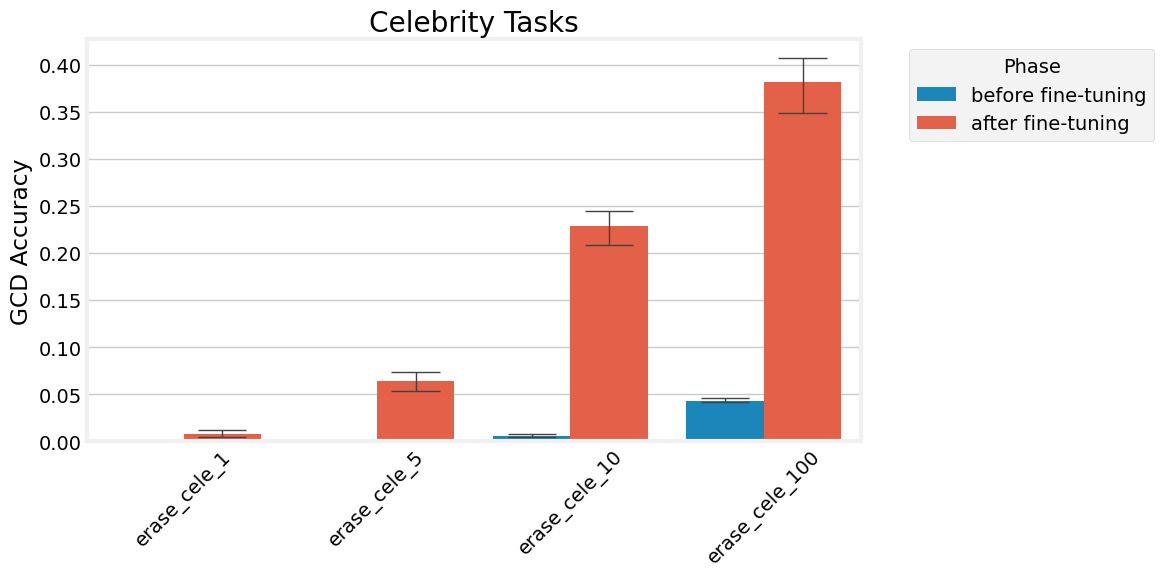

Figure saved as 'figures/warmup/celebrity_warmup_impact.png'


In [3]:
change = 'warmup'
change_str = 'baseline'
    
for task in ['object', 'art', 'celebrity']:

    metric = metric_map[task]

    plt.style.use('fivethirtyeight')

    df_fig = df[df['change'].str.contains(change_str, na=False)]
    df_fig = df_fig[df_fig['task'] == task]
    df_fig = df_fig[df_fig['metric'] == metric]
    df_fig = df_fig[(df_fig['finetune_prompts'].str.contains("_random_concepts_seed0", na=False)) | (df_fig['finetune_prompts'] == 'none')]
    # Map 'type' column values: 0 -> "erased", 1 -> "others"
    if task == 'art':
        df_fig['type'] = df_fig['type'].map({"0": "erased", "1": "others"})
        
    #df_fig = df_fig[df_fig['finetune_task'] == task]
    #df_fig = df_fig[df_fig['type'] != 'others']
    df_fig['value'] = df_fig['value'].apply(lambda x: float(x.split('±')[0]) if isinstance(x, str) and '±' in x else float(x))

    # Filter out 'full' type and keep only 'none' and 'lora'
    df_fig = df_fig[df_fig['finetune_algo'].isin(['none', 'lora'])]
    df_fig = df_fig[df_fig['finetune_task'].isin([task, 'none'])]
    df_fig = df_fig[df_fig['type'].isin(['erased'])]
    #print(df_fig)
    
    if task == 'celebrity':
        df_fig['config_num'] = df_fig['config'].str.extract('(\d+)$').astype(int)
        df_fig = df_fig.sort_values('config_num')
        custom_order = df_fig['config'].unique()
        df_fig = df_fig.drop('config_num', axis=1)


    # Create a new 'phase' column based on 'finetune_algo'
    df_fig['phase'] = df_fig['finetune_algo'].map({'none': 'before fine-tuning', 'lora': 'after fine-tuning'})

    # Create a single figure
    fig, ax = plt.subplots(figsize=(12, 6))
    fig.patch.set_facecolor('white')  # Set figure background to white
    ax.set_facecolor('white')  # Set axes background to white

    grouped = df_fig.groupby(['config', 'phase'])
    invalid_groups = [name for name, group in grouped if len(group) != 3]
    
    if invalid_groups:
        print("The following groups have an incorrect number of values:")
        for name in invalid_groups:
            group = grouped.get_group(name)
            print(f"Group {name} has {len(group)} values:")
            print(group)
        
        # Raise an exception to halt execution
        #raise ValueError("Some groups have an incorrect number of values. Please check the data and try again.")
            
    sns.barplot(data=df_fig, x='config', y='value', hue='phase', ax=ax, order=df_fig['config'].unique(), capsize=0.5, err_kws={'linewidth': 1})

    ax.set_title(f'{task.capitalize()} Tasks')
    ax.set_xlabel('')
    #ax.set_xlabel('Task')
    ax.set_ylabel(metric_str[metric])
    ax.tick_params(axis='x', rotation=45)

    ax.legend(title='Phase', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

    os.makedirs('figures/warmup', exist_ok=True)

    # Save the figure
    fig.savefig(f'figures/warmup/{task}_warmup_impact.png', dpi=300, bbox_inches='tight', facecolor='white')
    print(f"Figure saved as 'figures/warmup/{task}_warmup_impact.png'")


Task object: The following groups have an incorrect number of values:
Group ('erase_ship', 'before fine-tuning') has 4 values:
     algo    change    task      config finetune_algo finetune_task  \
102  MACE  baseline  object  erase_ship          none          none   
126  MACE  baseline  object  erase_ship          none          none   
150  MACE  baseline  object  erase_ship          none          none   
153  MACE  baseline  object  erase_ship          none          none   

    finetune_prompts           prompts_csv seed    type    metric  value  \
102             none  object_ship_concepts    1  erased  clip_acc  0.105   
126             none  object_ship_concepts    2  erased  clip_acc  0.105   
150             none  object_ship_concepts    0  erased  clip_acc  0.060   
153             none  object_ship_concepts    0  erased  clip_acc  0.065   

                  phase  
102  before fine-tuning  
126  before fine-tuning  
150  before fine-tuning  
153  before fine-tuning  
Task c

/tmp/ipykernel_1904009/2316343338.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=32)
/tmp/ipykernel_1904009/2316343338.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=32)
/tmp/ipykernel_1904009/2316343338.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=32)
/tmp/ipykernel_1904009/2316343338.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=32)


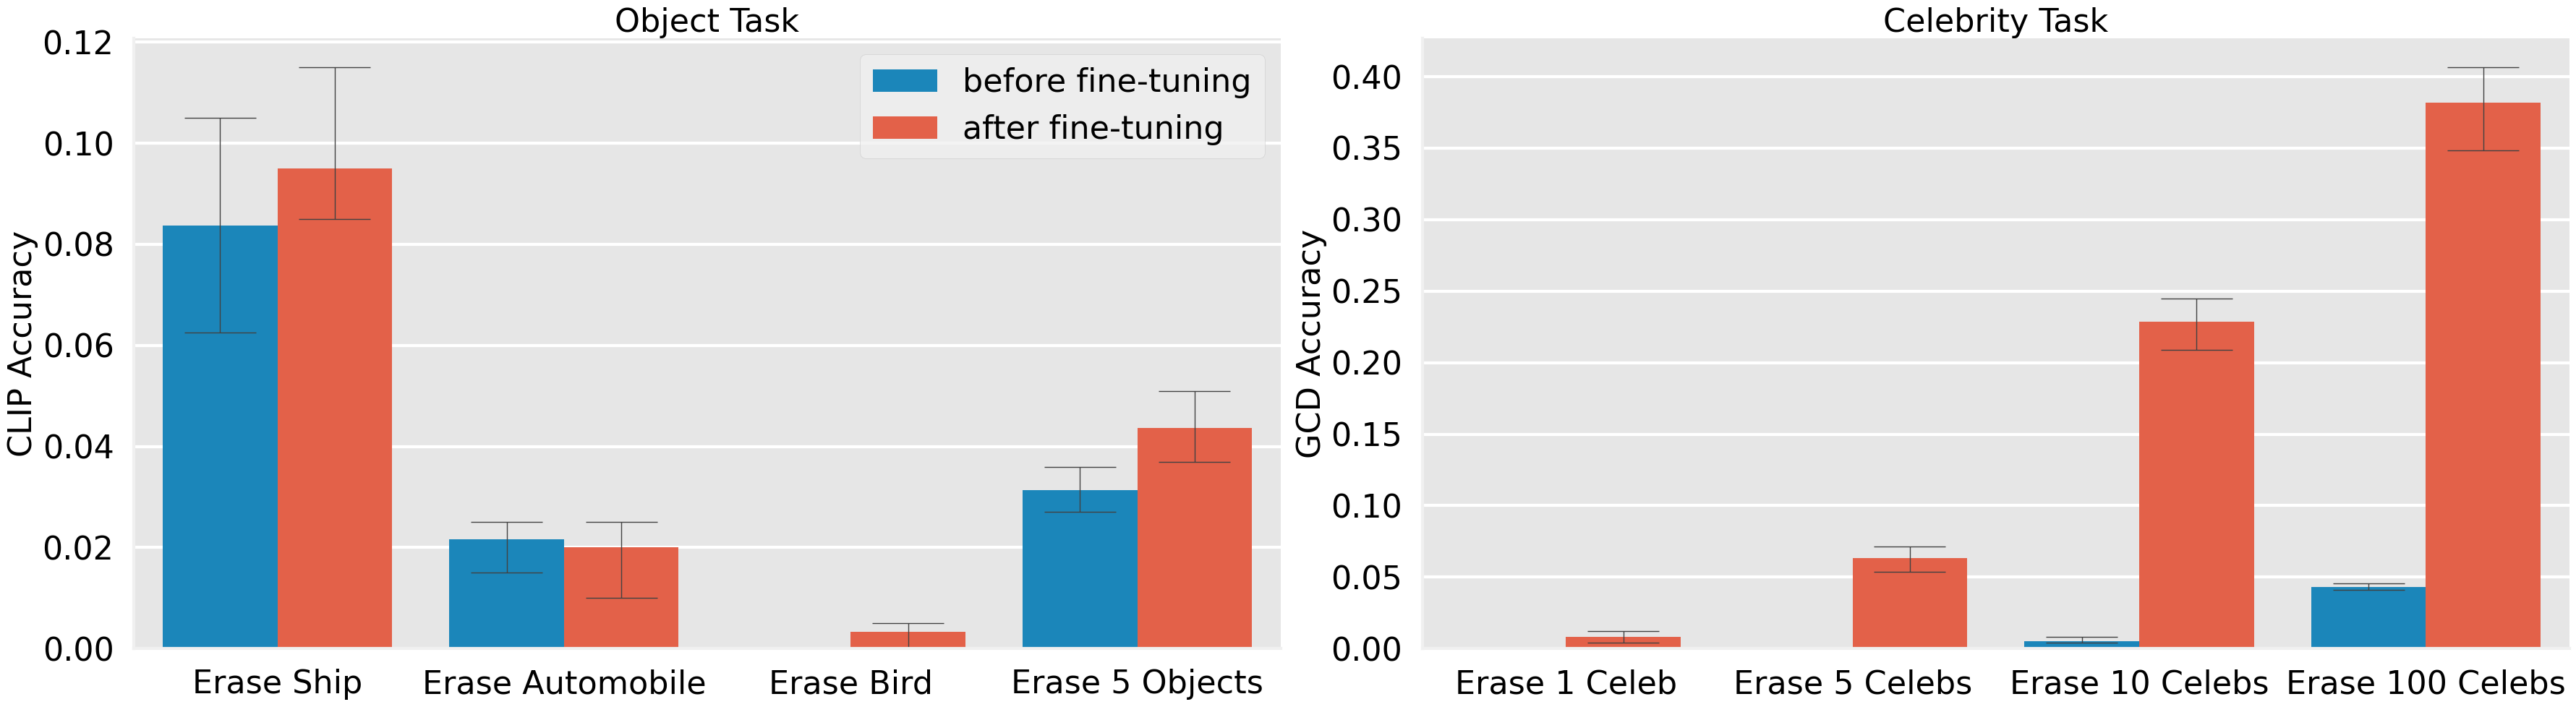

Figure saved as 'figures/warmup/all_tasks_warmup_impact.png'


In [4]:
# Create a main figure with subplots for each task
tasks = ['object', 'celebrity']


fig, axes = plt.subplots(1, len(tasks), figsize=(36, 10))
fig.patch.set_facecolor('white')  # Set figure background to white

change = 'warmup'
change_str = 'baseline'

for idx, task in enumerate(tasks):
    metric = metric_map[task]
    
    plt.style.use('fivethirtyeight')

    df_fig = df[df['change'].str.contains(change_str, na=False)]
    df_fig = df_fig[df_fig['task'] == task]
    df_fig = df_fig[df_fig['metric'] == metric]
    df_fig = df_fig[(df_fig['finetune_prompts'].str.contains("_random_concepts_seed0", na=False)) | (df_fig['finetune_prompts'] == 'none')]
    df_fig = df_fig[df_fig['finetune_task'].isin([task, 'none'])]
    df_fig = df_fig[df_fig['type'].isin(['erased'])]
    df_fig['value'] = df_fig['value'].apply(lambda x: float(x.split('±')[0]) if isinstance(x, str) and '±' in x else float(x))
    if task == 'art':
        df_fig['type'] = df_fig['type'].map({"0": "erased", "1": "others"})

    df_fig = df_fig[df_fig['finetune_algo'].isin(['none', 'lora'])]

    df_fig['phase'] = df_fig['finetune_algo'].map({'none': 'before fine-tuning', 'lora': 'after fine-tuning'})

    if task == 'celebrity':
        df_fig['config_num'] = df_fig['config'].str.extract('(\d+)$').astype(int)
        df_fig = df_fig.sort_values('config_num')
        custom_order = df_fig['config'].unique()
        df_fig = df_fig.drop('config_num', axis=1)

    ax = axes[idx]
    ax.set_facecolor('white')  # Set axes background to white

    grouped = df_fig.groupby(['config', 'phase'])
    invalid_groups = [name for name, group in grouped if len(group) != 3]
    
    if invalid_groups:
        print(f"Task {task}: The following groups have an incorrect number of values:")
        for name in invalid_groups:
            group = grouped.get_group(name)
            print(f"Group {name} has {len(group)} values:")
            print(group)
    
    df_fig['config'] = df_fig['config'].apply(lambda x: x_axis_labels[x])
    sns.barplot(data=df_fig, x='config', y='value', hue='phase', ax=ax, order=df_fig['config'].unique(), capsize=0.5, err_kws={'linewidth': 1})

    # remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x')
    ax.tick_params(axis='y')
    
    ax.set_title(f'{task.capitalize()} Task', fontsize=32)
    ax.set_xlabel('')
    ax.set_ylabel(metric_str[metric], fontsize=32)
    # set font size of legend, x axis labels, y axis labels
    
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=32)
    
    # Increase space between x-axis labels and plot
    ax.tick_params(axis='x', which='major', pad=20)
    ax.tick_params(axis='y', which='major', pad=20)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=32)

    ax.set_facecolor('#E6E6E6')  # Light gray background
    ax.grid(color='white', linestyle='-', linewidth=3, axis='y')
    ax.set_axisbelow(True)  # Ensure grid is behind the bars


    handles, labels = ax.get_legend_handles_labels()
    if idx == 0:  # Only show legend for the last subplot
        ax.legend(handles, labels, title='', loc='upper right', fontsize=32)
    else:
        ax.legend().remove()

plt.tight_layout()
plt.show()

# Save the figure
os.makedirs('figures/warmup', exist_ok=True)
fig.savefig(f'figures/warmup/all_tasks_warmup_impact.png', dpi=300, bbox_inches='tight', facecolor='white')
print(f"Figure saved as 'figures/warmup/all_tasks_warmup_impact.png'")




Task art: The following groups have an incorrect number of values:
Group ('erase_art_100', 'after fine-tuning') has 1 values:
    algo    change task         config finetune_algo finetune_task  \
77  MACE  baseline  art  erase_art_100          lora           art   

             finetune_prompts prompts_csv seed type      metric    value  \
77  art_random_concepts_seed0     coco_5k    0  NaN  clip_score  14.6344   

                phase  
77  after fine-tuning  
Task celebrity: The following groups have an incorrect number of values:
Group ('erase_cele_1', 'after fine-tuning') has 2 values:
     algo    change       task        config finetune_algo finetune_task  \
189  MACE  baseline  celebrity  erase_cele_1          lora     celebrity   
190  MACE  baseline  celebrity  erase_cele_1          lora     celebrity   

                    finetune_prompts prompts_csv seed        type      metric  \
189  celebrity_random_concepts_seed0     coco_5k    0  mscoco-10k  clip_score   
190  celeb

/tmp/ipykernel_1904009/64808155.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=32)
/tmp/ipykernel_1904009/64808155.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=32)
/tmp/ipykernel_1904009/64808155.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=32)
/tmp/ipykernel_1904009/64808155.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=32)


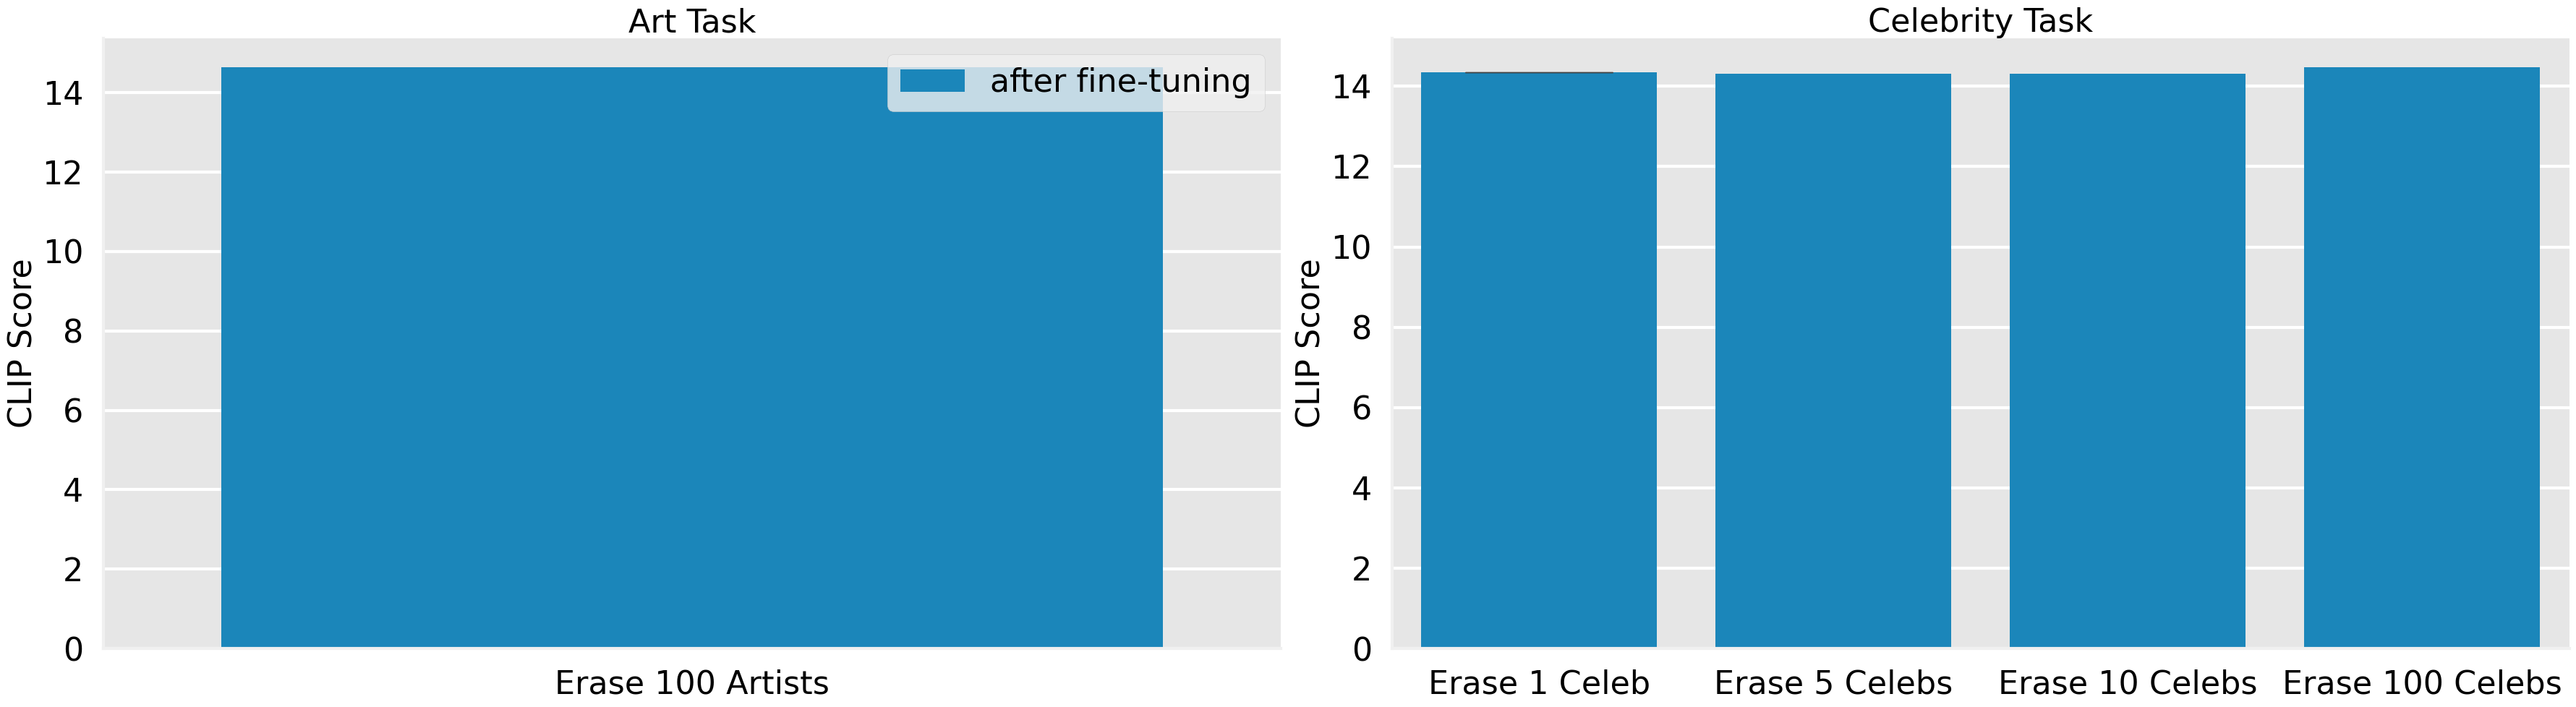

In [5]:
# Create a main figure with subplots for each task
tasks = ['art', 'celebrity']


fig, axes = plt.subplots(1, len(tasks), figsize=(36, 10))
fig.patch.set_facecolor('white')  # Set figure background to white

change = 'warmup'
change_str = 'baseline'

for idx, task in enumerate(tasks):
    metric = 'clip_score'
    
    plt.style.use('fivethirtyeight')

    df_fig = df[df['change'].str.contains(change_str, na=False)]
    df_fig = df_fig[df_fig['task'] == task]
    df_fig = df_fig[df_fig['metric'] == metric]
    df_fig = df_fig[(df_fig['finetune_prompts'].str.contains("_random_concepts_seed0", na=False)) | (df_fig['finetune_prompts'] == 'none')]
    df_fig = df_fig[df_fig['finetune_task'].isin([task, 'none'])]
    df_fig = df_fig[df_fig['type'] == 'mscoco-10k']
    df_fig['value'] = df_fig['value'].apply(lambda x: float(x.split('±')[0]) if isinstance(x, str) and '±' in x else float(x))
    if task == 'art':
        df_fig['type'] = df_fig['type'].map({"0": "erased", "1": "others"})

    df_fig = df_fig[df_fig['finetune_algo'].isin(['none', 'lora'])]

    df_fig['phase'] = df_fig['finetune_algo'].map({'none': 'before fine-tuning', 'lora': 'after fine-tuning'})

    if task == 'celebrity':
        df_fig['config_num'] = df_fig['config'].str.extract('(\d+)$').astype(int)
        df_fig = df_fig.sort_values('config_num')
        custom_order = df_fig['config'].unique()
        df_fig = df_fig.drop('config_num', axis=1)

    ax = axes[idx]
    ax.set_facecolor('white')  # Set axes background to white

    grouped = df_fig.groupby(['config', 'phase'])
    invalid_groups = [name for name, group in grouped if len(group) != 3]
    
    if invalid_groups:
        print(f"Task {task}: The following groups have an incorrect number of values:")
        for name in invalid_groups:
            group = grouped.get_group(name)
            print(f"Group {name} has {len(group)} values:")
            print(group)
    
    df_fig['config'] = df_fig['config'].apply(lambda x: x_axis_labels[x])
    sns.barplot(data=df_fig, x='config', y='value', hue='phase', ax=ax, order=df_fig['config'].unique(), capsize=0.5, err_kws={'linewidth': 1})

    # remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x')
    ax.tick_params(axis='y')
    
    ax.set_title(f'{task.capitalize()} Task', fontsize=32)
    ax.set_xlabel('')
    ax.set_ylabel(metric_str[metric], fontsize=32)
    # set font size of legend, x axis labels, y axis labels
    
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=32)
    
    # Increase space between x-axis labels and plot
    ax.tick_params(axis='x', which='major', pad=20)
    ax.tick_params(axis='y', which='major', pad=20)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=32)

    ax.set_facecolor('#E6E6E6')  # Light gray background
    ax.grid(color='white', linestyle='-', linewidth=3, axis='y')
    ax.set_axisbelow(True)  # Ensure grid is behind the bars


    handles, labels = ax.get_legend_handles_labels()
    if idx == 0:  # Only show legend for the last subplot
        ax.legend(handles, labels, title='', loc='upper right', fontsize=32)
    else:
        ax.legend().remove()

plt.tight_layout()
plt.show()

# Save the figure
os.makedirs('figures/warmup', exist_ok=True)
#fig.savefig(f'figures/warmup/all_tasks_warmup_impact.png', dpi=300, bbox_inches='tight', facecolor='white')
#print(f"Figure saved as 'figures/warmup/all_tasks_warmup_impact.png'")

/tmp/ipykernel_1904009/4200734021.py:47: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.barplot(data=df_fig, x='change_value', y='value', hue='type', ax=ax, order=df_fig['change_value'].unique(), capsize=0.5, errwidth=1)


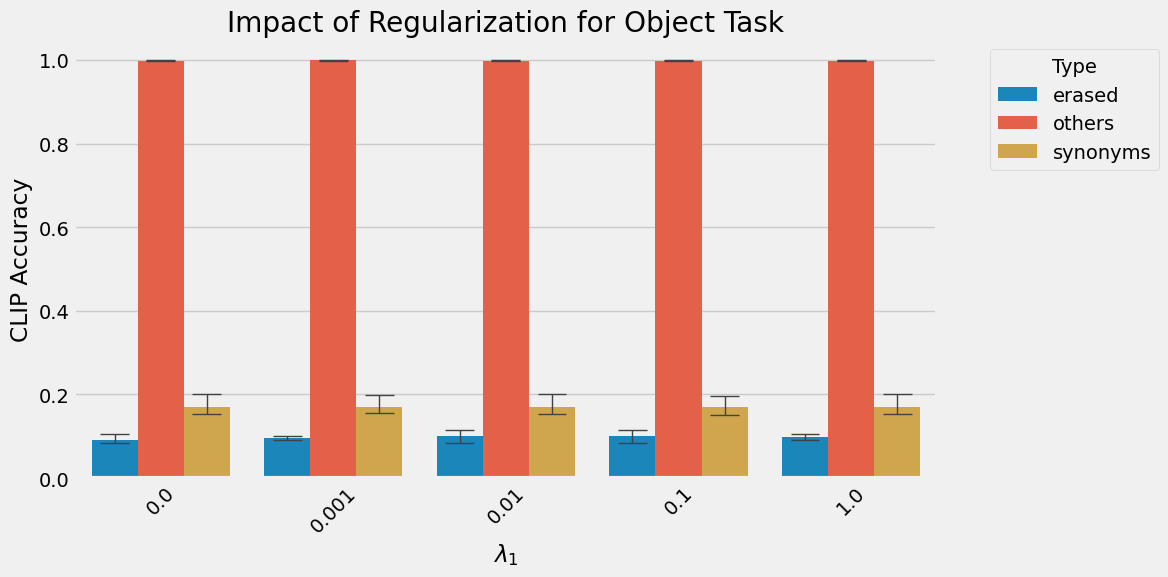

Figure saved as 'figures/regularization/object_regularization_impact.png'
The following groups have an incorrect number of values:
Group ('car_reg=0.0', 'erased') has 6 values:
    algo       change task         config finetune_algo finetune_task  \
11  MACE  car_reg=0.0  art  erase_art_100          lora           art   
13  MACE  car_reg=0.0  art  erase_art_100          lora           art   
15  MACE  car_reg=0.0  art  erase_art_100          lora           art   
17  MACE  car_reg=0.0  art  erase_art_100          lora           art   
19  MACE  car_reg=0.0  art  erase_art_100          lora           art   
21  MACE  car_reg=0.0  art  erase_art_100          lora           art   

             finetune_prompts       prompts_csv seed    type      metric  \
11  art_random_concepts_seed0  art_100_concepts    0  erased  clip_score   
13  art_random_concepts_seed0  art_100_concepts    0  erased  clip_score   
15  art_random_concepts_seed0  art_100_concepts    1  erased  clip_score   
17  art

/tmp/ipykernel_1904009/4200734021.py:47: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.barplot(data=df_fig, x='change_value', y='value', hue='type', ax=ax, order=df_fig['change_value'].unique(), capsize=0.5, errwidth=1)


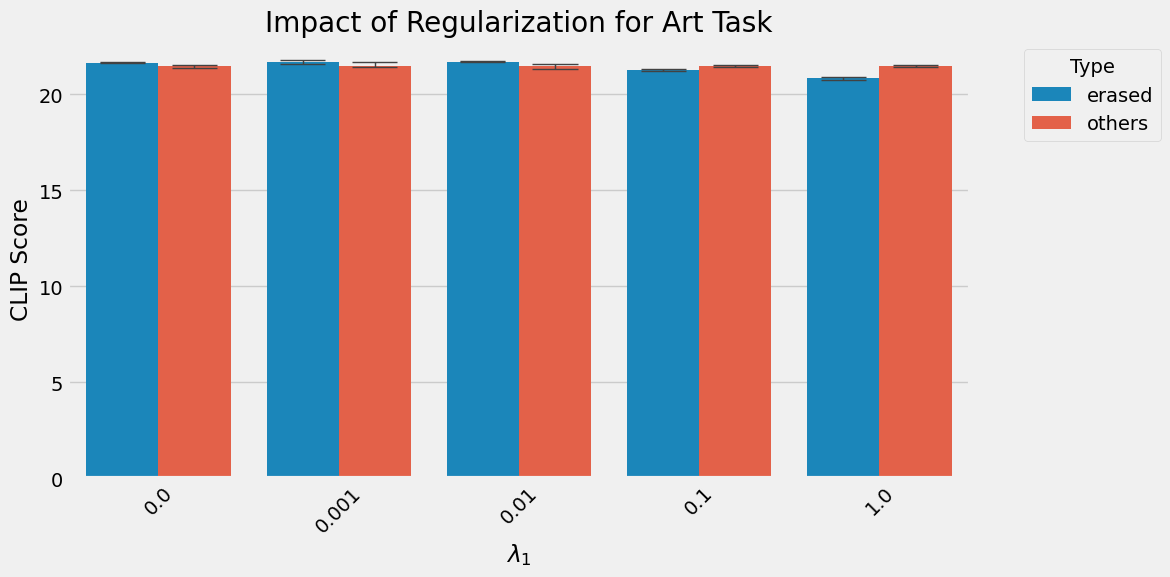

Figure saved as 'figures/regularization/art_regularization_impact.png'
The following groups have an incorrect number of values:
Group ('car_reg=0.0', 'erased') has 5 values:
    algo       change       task         config finetune_algo finetune_task  \
23  MACE  car_reg=0.0  celebrity  erase_cele_10          lora     celebrity   
25  MACE  car_reg=0.0  celebrity  erase_cele_10          lora     celebrity   
27  MACE  car_reg=0.0  celebrity  erase_cele_10          lora     celebrity   
28  MACE  car_reg=0.0  celebrity  erase_cele_10          lora     celebrity   
31  MACE  car_reg=0.0  celebrity  erase_cele_10          lora     celebrity   

                   finetune_prompts            prompts_csv seed    type  \
23  celebrity_random_concepts_seed0  celebrity_10_concepts    1  erased   
25  celebrity_random_concepts_seed0  celebrity_10_concepts    2  erased   
27  celebrity_random_concepts_seed0  celebrity_10_concepts    0  erased   
28  celebrity_random_concepts_seed0  celebrity_10_c

/tmp/ipykernel_1904009/4200734021.py:47: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.barplot(data=df_fig, x='change_value', y='value', hue='type', ax=ax, order=df_fig['change_value'].unique(), capsize=0.5, errwidth=1)


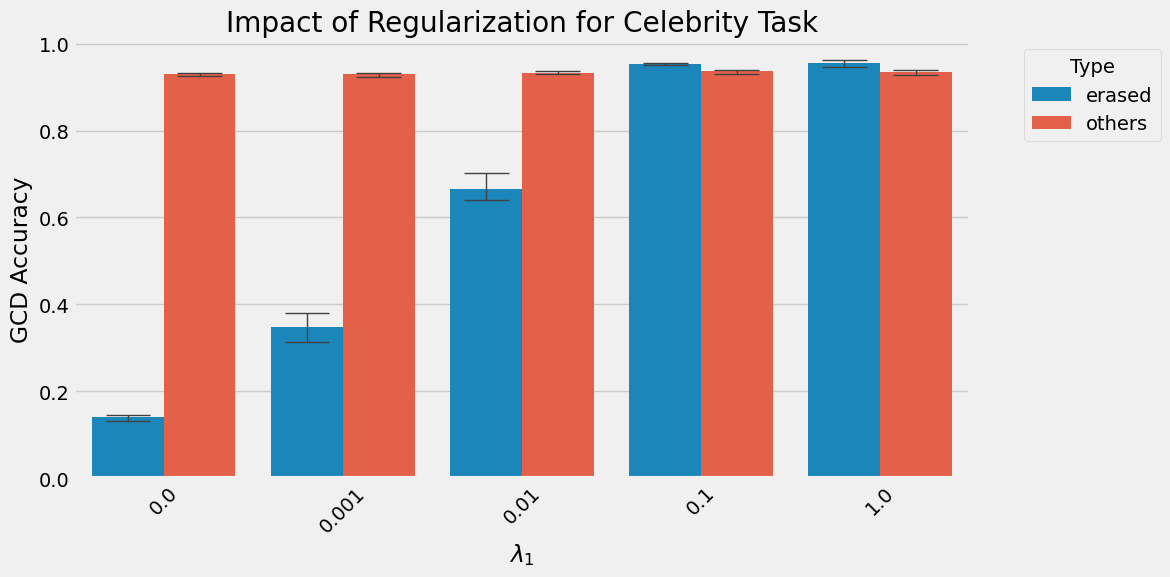

Figure saved as 'figures/regularization/celebrity_regularization_impact.png'


In [6]:
change = 'regularization'
change_str = 'car_reg'
task = 'object'

    
for task in ['object', 'art', 'celebrity']:

    metric = metric_map[task]
    plt.style.use('fivethirtyeight')

    df_fig = df[df['change'].str.contains(change_str, na=False)]
    df_fig = df_fig[df_fig['task'] == task]
    df_fig = df_fig[df_fig['metric'] == metric]
    df_fig = df_fig[df_fig['finetune_prompts'].str.contains("_random_concepts_seed0", na=False)]
    df_fig = df_fig[df_fig['finetune_task'].isin([task, 'none'])]
    df_fig = df_fig[(df_fig['finetune_prompts'].str.contains("_random_concepts_seed0", na=False)) | (df_fig['finetune_prompts'] == 'none')]
    
    #df_fig = df_fig[df_fig['type'] != 'others']
    df_fig['value'] = df_fig['value'].apply(lambda x: float(x.split('±')[0]) if isinstance(x, str) and '±' in x else float(x))
    if task == 'art':
        df_fig['type'] = df_fig['type'].map({"0": "erased", "1": "others"})

    # Filter out 'full' type and keep only 'n/a' and 'lora'
    df_fig = df_fig[df_fig['finetune_algo'].isin(['n/a', 'lora'])]

    # Extract the numeric value from 'change' column and sort
    df_fig['change_value'] = df_fig['change'].str.extract('(\d+(?:\.\d+)?)').astype(float)
    df_fig = df_fig[df_fig['change_value'].isin([0, 0.001, 0.01, 0.1, 1])]
    
    df_fig = df_fig.sort_values('change_value')

    # Create a single figure
    fig, ax = plt.subplots(figsize=(12, 6))
    #fig.suptitle(f'{task.capitalize()} Task', fontsize=16)

    grouped = df_fig.groupby(['change', 'type'])
    invalid_groups = [name for name, group in grouped if len(group) != 3]
    
    if invalid_groups:
        print("The following groups have an incorrect number of values:")
        for name in invalid_groups:
            group = grouped.get_group(name)
            print(f"Group {name} has {len(group)} values:")
            print(group)

    # Plot the data with sorted x-axis and smaller confidence interval bars
    sns.barplot(data=df_fig, x='change_value', y='value', hue='type', ax=ax, order=df_fig['change_value'].unique(), capsize=0.5, errwidth=1)

    ax.set_title(f'Impact of Regularization for {task.capitalize()} Task')
    ax.set_xlabel(r'$\lambda_1$')
    ax.set_ylabel(metric_str[metric])
    ax.tick_params(axis='x', rotation=45)

    ax.legend(title='Type', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

    # Create the 'figures/regularization' directory if it doesn't exist
    import os
    os.makedirs('figures/regularization', exist_ok=True)

    # Save the figure
    fig.savefig(f'figures/regularization/{task}_regularization_impact.png', dpi=300, bbox_inches='tight')
    print(f"Figure saved as 'figures/regularization/{task}_regularization_impact.png'")


Number of rows with change = 'car_reg=0.0001':      algo          change    task          config finetune_algo finetune_task  \
35   MACE  car_reg=0.0001     art   erase_art_100          none          none   
36   MACE  car_reg=0.0001     art   erase_art_100          none          none   
37   MACE  car_reg=0.0001     art   erase_art_100          lora           art   
38   MACE  car_reg=0.0001     art   erase_art_100          lora           art   
39   MACE  car_reg=0.0001     art   erase_art_100          lora           art   
..    ...             ...     ...             ...           ...           ...   
601  MACE  car_reg=0.0001  object  erase_object_5          lora        object   
602  MACE  car_reg=0.0001     art   erase_art_100          lora           art   
603  MACE  car_reg=0.0001     art   erase_art_100          lora           art   
604  MACE  car_reg=0.0001     art   erase_art_100          lora           art   
605  MACE  car_reg=0.0001     art   erase_art_100          lor

/tmp/ipykernel_1904009/3276375389.py:80: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=24)
/tmp/ipykernel_1904009/3276375389.py:85: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=24)
/tmp/ipykernel_1904009/3276375389.py:90: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=32)
/tmp/ipykernel_1904009/3276375389.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=32)


Number of rows with change = 'car_reg=0.0001':      algo          change    task          config finetune_algo finetune_task  \
35   MACE  car_reg=0.0001     art   erase_art_100          none          none   
36   MACE  car_reg=0.0001     art   erase_art_100          none          none   
37   MACE  car_reg=0.0001     art   erase_art_100          lora           art   
38   MACE  car_reg=0.0001     art   erase_art_100          lora           art   
39   MACE  car_reg=0.0001     art   erase_art_100          lora           art   
..    ...             ...     ...             ...           ...           ...   
601  MACE  car_reg=0.0001  object  erase_object_5          lora        object   
602  MACE  car_reg=0.0001     art   erase_art_100          lora           art   
603  MACE  car_reg=0.0001     art   erase_art_100          lora           art   
604  MACE  car_reg=0.0001     art   erase_art_100          lora           art   
605  MACE  car_reg=0.0001     art   erase_art_100          lor

/tmp/ipykernel_1904009/3276375389.py:80: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=24)
/tmp/ipykernel_1904009/3276375389.py:85: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=24)
/tmp/ipykernel_1904009/3276375389.py:90: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=32)
/tmp/ipykernel_1904009/3276375389.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=32)


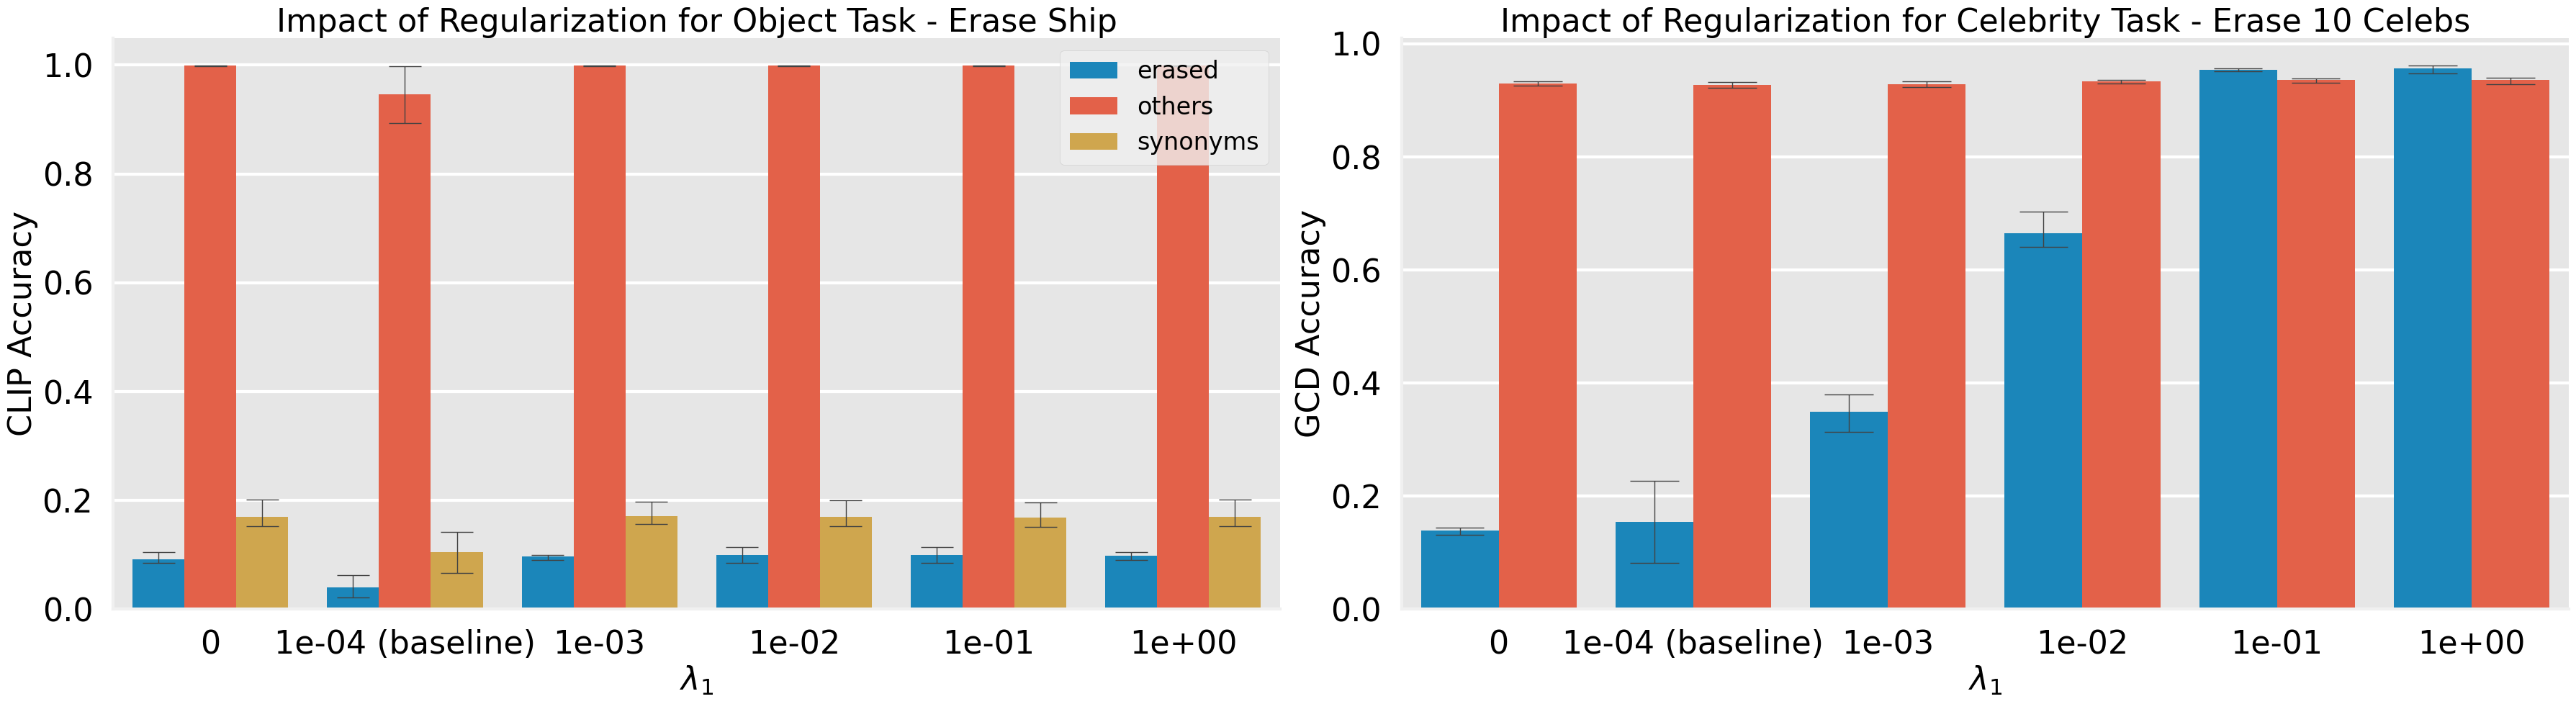

Figure saved as 'figures/regularization/all_tasks_regularization_impact.png'


In [7]:
# Create a main figure with subplots for each task
tasks = ['object', 'celebrity']

fig, axes = plt.subplots(1, len(tasks), figsize=(36, 10))
fig.patch.set_facecolor('white')  # Set figure background to white

change = 'regularization'
change_str = 'car_reg'

for idx, task in enumerate(tasks):
    metric = metric_map[task]
    
    plt.style.use('fivethirtyeight')

    df_fig = df.copy()
    df_fig.loc[df_fig['change'].str.contains('baseline', case=False, na=False), 'change'] = 'car_reg=0.0001'

    # Count and print the number of rows with change = 'car_reg=0.0001'
    num_rows = df_fig[df_fig['change'] == 'car_reg=0.0001']
    print(f"Number of rows with change = 'car_reg=0.0001': {num_rows}")
    df_fig = df_fig[df_fig['change'].str.contains(change_str, na=False)]
    num_rows = df_fig[df_fig['change'] == 'car_reg=0.0001']
    print(f"Number of rows with change = 'car_reg=0.0001': {num_rows}")
    df_fig = df_fig[df_fig['task'] == task]
    df_fig = df_fig[df_fig['metric'] == metric]
    df_fig = df_fig[df_fig['finetune_prompts'].str.contains("_random_concepts_seed0", na=False)]
    df_fig = df_fig[df_fig['finetune_task'].isin([task, 'none'])]
    #df_fig = df_fig[df_fig['type'].isin(['erased', 'synonyms'])]
    df_fig = df_fig[(df_fig['finetune_prompts'].str.contains("_random_concepts_seed0", na=False)) | (df_fig['finetune_prompts'] == 'none')]
    df_fig = df_fig[df_fig['prompts_csv'] != 'coco_5k']
    df_fig['value'] = df_fig['value'].apply(lambda x: float(x.split('±')[0]) if isinstance(x, str) and '±' in x else float(x))
    if task == 'art':
        df_fig['type'] = df_fig['type'].map({"0": "erased", "1": "others"})
    
    # Filter out 'full' type and keep only 'n/a' and 'lora'
    df_fig = df_fig[df_fig['finetune_algo'].isin(['n/a', 'lora'])]

    ax = axes[idx]
    ax.set_facecolor('white')  # Set axes background to white

    df_fig['change_value'] = df_fig['change'].str.extract('(\d+(?:\.\d+)?)').astype(float)
    
    df_fig = df_fig[df_fig['change_value'].isin([0, 0.0001, 0.001, 0.01, 0.1, 1])]
    
    df_fig = df_fig.sort_values('change_value')

    grouped = df_fig.groupby(['change', 'type'])
    invalid_groups = [name for name, group in grouped if len(group) != 3]
    
    if invalid_groups:
        print(f"Task {task}: The following groups have an incorrect number of values:")
        for name in invalid_groups:
            group = grouped.get_group(name)
            print(f"Group {name} has {len(group)} values:")
            print(group)
    
    df_fig['config'] = df_fig['config'].apply(lambda x: x_axis_labels.get(x, x))
    df_fig['change_value'] = df_fig['change_value'].astype(float)
    df_fig['change_value'] = df_fig['change_value'].apply(lambda x: '0' if x == 0 else f'{x:.0e}')
    df_fig.loc[df_fig['change_value'] == '1e-04', 'change_value'] = '1e-04 (baseline)'
    
    df_fig['sort_value'] = df_fig['change_value'].apply(lambda x: float(x.split()[0]) if 'baseline' not in x else 1e-4)
    df_fig = df_fig.sort_values('sort_value')
    
    # Set the order for the x-axis
    order = ['0', '1e-04 (baseline)', '1e-03', '1e-02', '1e-01', '1e+00']
    sns.barplot(data=df_fig, x='change_value', y='value', hue='type', ax=ax, order=df_fig['change_value'].unique(), capsize=0.5, err_kws={'linewidth': 1})

    # remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x')
    ax.tick_params(axis='y')
    
    ax.set_title(f'Impact of Regularization for {task.capitalize()} Task - {df_fig["config"].iloc[0]}', fontsize=32)
    ax.set_xlabel(r'$\lambda_1$', fontsize=32)
    ax.tick_params(axis='x', rotation=0)

    # set font size of legend, x axis labels, y axis labels
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=24)
    
    # Increase space between x-axis labels and plot
    ax.tick_params(axis='x', which='major', pad=20)
    ax.tick_params(axis='y', which='major', pad=20)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=24)
    
    ax.set_ylabel(metric_str[metric], fontsize=32)
    # set font size of legend, x axis labels, y axis labels
    
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=32)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=32)

    ax.set_facecolor('#E6E6E6')  # Light gray background
    ax.grid(color='white', linestyle='-', linewidth=3, axis='y')
    ax.set_axisbelow(True)  # Ensure grid is behind the bars


    handles, labels = ax.get_legend_handles_labels()
    if idx == 0:  # Only show legend for the first subplot
        ax.legend(handles, labels, title='', loc='upper right', fontsize=24)
    else:
        ax.legend().remove()

plt.tight_layout()
plt.show()

# Save the figure
os.makedirs('figures/regularization', exist_ok=True)
fig.savefig(f'figures/regularization/all_tasks_regularization_impact.png', dpi=300, bbox_inches='tight', facecolor='white')
print(f"Figure saved as 'figures/regularization/all_tasks_regularization_impact.png'")

Task art: The following groups have an incorrect number of values:
Group ('car_reg=0.0', 'mscoco-10k') has 1 values:
    algo       change task         config finetune_algo finetune_task  \
10  MACE  car_reg=0.0  art  erase_art_100          lora           art   

             finetune_prompts prompts_csv seed        type metric      value  \
10  art_random_concepts_seed0     coco_5k    0  mscoco-10k    FID  20.205262   

    change_value  
10           0.0  
Group ('car_reg=0.0001', 'mscoco-10k') has 2 values:
    algo          change task         config finetune_algo finetune_task  \
78  MACE  car_reg=0.0001  art  erase_art_100          lora           art   
79  MACE  car_reg=0.0001  art  erase_art_100          lora           art   

             finetune_prompts prompts_csv seed        type metric     value  \
78  art_random_concepts_seed0     coco_5k    0  mscoco-10k    FID  20.18822   
79  art_random_concepts_seed0     coco_5k    0  mscoco-10k    FID  20.18847   

    change_value 

/tmp/ipykernel_1904009/3162384059.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=24)
/tmp/ipykernel_1904009/3162384059.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=24)
/tmp/ipykernel_1904009/3162384059.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=32)
/tmp/ipykernel_1904009/3162384059.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=32)
/tmp/ipykernel_1904009/3162384059.py:59: UserWarning: set_ticklabels() should only be used with a fi

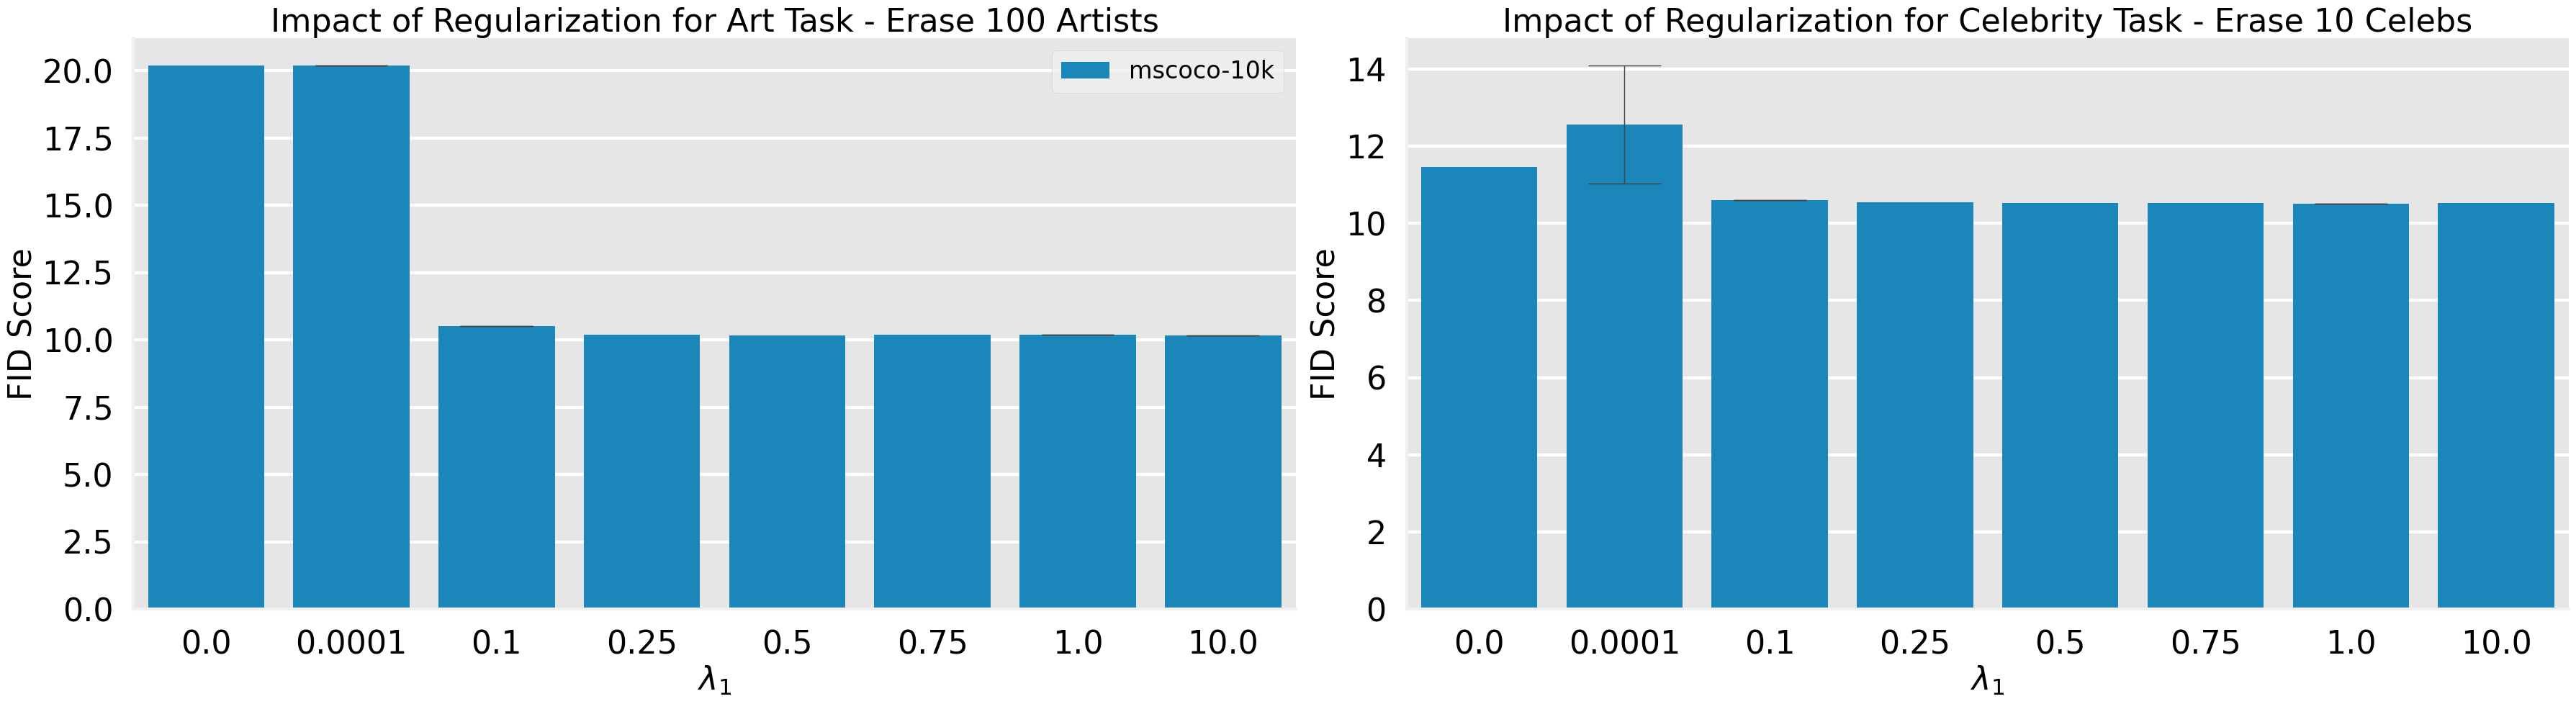

Figure saved as 'figures/regularization/all_tasks_regularization_impact.png'


In [8]:
# Create a main figure with subplots for each task
tasks = ['art', 'celebrity']

fig, axes = plt.subplots(1, len(tasks), figsize=(36, 10))
fig.patch.set_facecolor('white')  # Set figure background to white

change = 'regularization'
change_str = 'car_reg'

for idx, task in enumerate(tasks):
    metric = 'FID'
    
    plt.style.use('fivethirtyeight')

    df_fig = df[df['change'].str.contains(change_str, na=False)]
    df_fig = df_fig[df_fig['task'] == task]
    df_fig = df_fig[df_fig['metric'] == metric]
    df_fig = df_fig[df_fig['finetune_prompts'].str.contains("_random_concepts_seed0", na=False)]
    df_fig = df_fig[df_fig['finetune_task'].isin([task, 'none'])]
    df_fig = df_fig[df_fig['prompts_csv'] == 'coco_5k']
    #df_fig = df_fig[df_fig['type'].isin(['erased', 'synonyms'])]
    df_fig = df_fig[(df_fig['finetune_prompts'].str.contains("_random_concepts_seed0", na=False)) | (df_fig['finetune_prompts'] == 'none')]
    df_fig['value'] = df_fig['value'].apply(lambda x: float(x.split('±')[0]) if isinstance(x, str) and '±' in x else float(x))
    
    df_fig = df_fig[df_fig['finetune_algo'].isin(['n/a', 'lora'])]

    ax = axes[idx]
    ax.set_facecolor('white')  # Set axes background to white
    
    df_fig['change_value'] = df_fig['change'].str.extract('(\d+(?:\.\d+)?)').astype(float)
    df_fig = df_fig.sort_values('change_value')
    

    grouped = df_fig.groupby(['change', 'type'])
    invalid_groups = [name for name, group in grouped if len(group) != 3]
    
    if invalid_groups:
        print(f"Task {task}: The following groups have an incorrect number of values:")
        for name in invalid_groups:
            group = grouped.get_group(name)
            print(f"Group {name} has {len(group)} values:")
            print(group)
    
    df_fig['config'] = df_fig['config'].apply(lambda x: x_axis_labels.get(x, x))
    
    sns.barplot(data=df_fig, x='change_value', y='value', hue='type', ax=ax, order=df_fig['change_value'].unique(), capsize=0.5, err_kws={'linewidth': 1})

    # remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x')
    ax.tick_params(axis='y')
    
    ax.set_title(f'Impact of Regularization for {task.capitalize()} Task - {df_fig["config"].iloc[0]}', fontsize=32)
    ax.set_xlabel(r'$\lambda_1$', fontsize=32)
    ax.tick_params(axis='x', rotation=0)

    # set font size of legend, x axis labels, y axis labels
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=24)
    
    # Increase space between x-axis labels and plot
    ax.tick_params(axis='x', which='major', pad=20)
    ax.tick_params(axis='y', which='major', pad=20)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=24)
    
    ax.set_ylabel(metric_str.get(metric, metric), fontsize=32)
    # set font size of legend, x axis labels, y axis labels
    
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=32)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=32)

    ax.set_facecolor('#E6E6E6')  # Light gray background
    ax.grid(color='white', linestyle='-', linewidth=3, axis='y')
    ax.set_axisbelow(True)  # Ensure grid is behind the bars


    handles, labels = ax.get_legend_handles_labels()
    if idx == 0:  # Only show legend for the first subplot
        ax.legend(handles, labels, title='', loc='upper right', fontsize=24)
    else:
        ax.legend().remove()

plt.tight_layout()
plt.show()

# Save the figure
os.makedirs('figures/regularization', exist_ok=True)
# fig.savefig(f'figures/regularization/all_tasks_regularization_impact.png', dpi=300, bbox_inches='tight', facecolor='white')
print(f"Figure saved as 'figures/regularization/all_tasks_regularization_impact.png'")

In [9]:
# change = 'finetuning'
# change_str = 'baseline'

# for task in ['object', 'art', 'celebrity']:

#     metric = metric_map[task]

#     plt.style.use('fivethirtyeight')

#     df_fig = df[df['change'].str.contains(change_str, na=False)]
#     df_fig = df_fig[df_fig['task'] == task]
#     df_fig = df_fig[df_fig['metric'] == metric]
#     df_fig = df_fig[df_fig['finetune_prompts'].str.contains("_random_concepts_seed0", na=False)]
#     df_fig = df_fig[df_fig['finetune_task'].isin([task, 'none'])]
#     df_fig['value'] = df_fig['value'].apply(lambda x: float(x.split('±')[0]) if isinstance(x, str) and '±' in x else float(x))
#     if task == 'art':
#         df_fig['type'] = df_fig['type'].map({"0": "erased", "1": "others"})

#     # Filter for 'full' and 'lora' finetune_algo, and 'erase_cele_10' config
#     df_fig = df_fig[df_fig['finetune_algo'].isin(['full', 'lora'])]
#     #df_fig = df_fig[df_fig['config'] == 'erase_ship']

#     # Include both 'erased' and 'others' types
#     #df_fig = df_fig[df_fig['type'].isin(['erased', 'others'])]

#     grouped = df_fig.groupby(['finetune_algo', 'type'])
#     invalid_groups = [name for name, group in grouped if len(group) != 3]
    
#     if invalid_groups:
#         print("The following groups have an incorrect number of values:")
#         for name in invalid_groups:
#             group = grouped.get_group(name)
#             print(f"Group {name} has {len(group)} values:")
#             print(group)

#     # Create a single figure
#     fig, ax = plt.subplots(figsize=(12, 6))

#     # Plot the data with finetune_algo on x-axis and type as hue
#     sns.barplot(data=df_fig, x='finetune_algo', y='value', hue='type', ax=ax, capsize=0.5, errwidth=1)

#     ax.set_title(f'{task.capitalize()} Tasks - {df_fig["config"].iloc[0]}')
#     ax.set_xlabel('Fine-tuning Algorithm')
#     ax.set_ylabel(metric_str[metric])
#     ax.tick_params(axis='x', rotation=0)

#     ax.set_facecolor('#E6E6E6')  # Light gray background
#     ax.grid(color='white', linestyle='-', linewidth=3, axis='y')
#     ax.set_axisbelow(True)  # Ensure grid is behind the bars


#     ax.legend(title='Type', bbox_to_anchor=(1.05, 1), loc='upper left')

#     plt.tight_layout()
#     plt.show()

#     # Create the 'figures/warmup' directory if it doesn't exist
#     import os
#     os.makedirs('figures/finetuning', exist_ok=True)

#     # Save the figure
#     fig.savefig(f'figures/finetuning/{task}_finetuning_comparison.png', dpi=300, bbox_inches='tight')
#     print(f"Figure saved as 'figures/finetuning/{task}_finetuning_comparison.png'")


Empty DataFrame
Columns: [algo, change, task, config, finetune_algo, finetune_task, finetune_prompts, prompts_csv, seed, type, metric, value]
Index: []


IndexError: single positional indexer is out-of-bounds

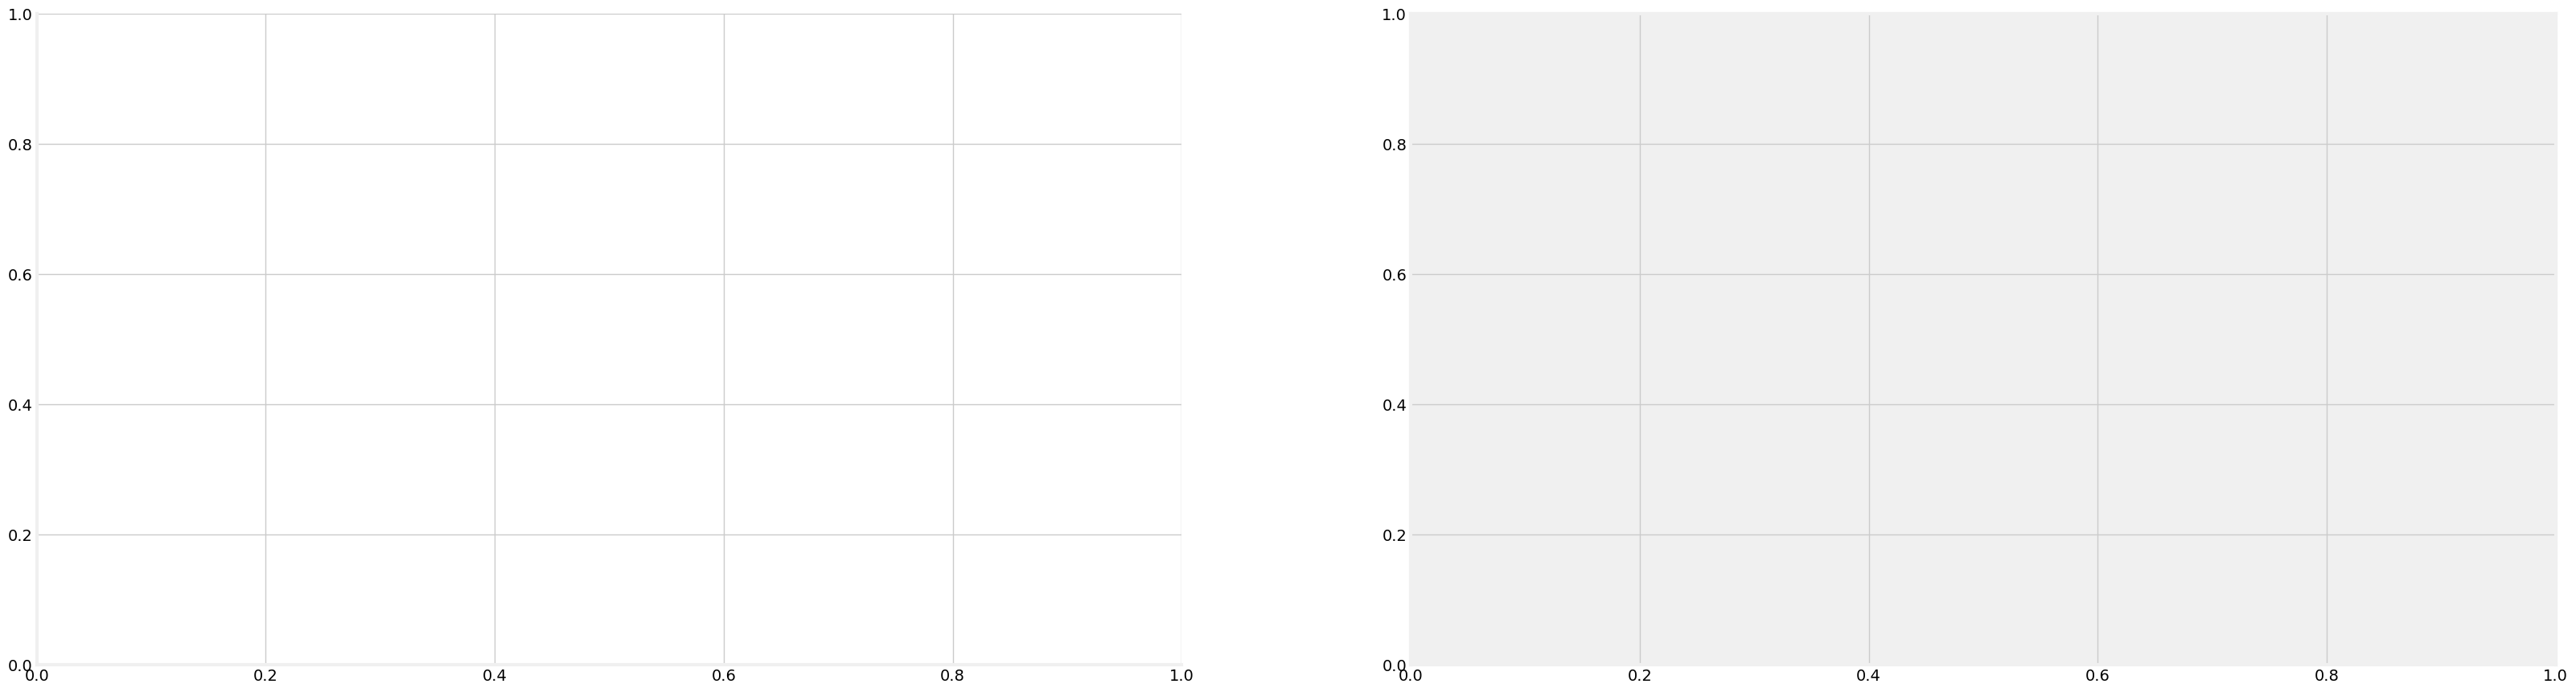

In [14]:
# Create a main figure with subplots for each task
tasks = ['object', 'celebrity']

fig, axes = plt.subplots(1, len(tasks), figsize=(36, 10))
fig.patch.set_facecolor('white')  # Set figure background to white

change = 'finetuning'
change_str = 'baseline'

for idx, task in enumerate(tasks):

    metric = metric_map[task]

    plt.style.use('fivethirtyeight')
    
    df_fig = df[df['change'].str.contains(change_str, na=False)]
    df_fig = df_fig[df_fig['task'] == task]
    df_fig = df_fig[df_fig['metric'] == metric]
    df_fig = df_fig[df_fig['type'] != 'mscoco-10k']
    df_fig = df_fig[df_fig['finetune_prompts'].str.contains("_random_concepts_seed0", na=False)]
    df_fig = df_fig[df_fig['finetune_task'].isin([task, 'none'])]
    df_fig['value'] = df_fig['value'].apply(lambda x: float(x.split('±')[0]) if isinstance(x, str) and '±' in x else float(x))
    # if task == 'art':
    #     df_fig['type'] = df_fig['type'].map({"0": "erased", "1": "others"})

    # Filter for 'full' and 'lora' finetune_algo, and 'erase_cele_10' config
    df_fig = df_fig[df_fig['finetune_algo'].isin(['full', 'lora'])]


    grouped = df_fig.groupby(['finetune_algo', 'type'])
    invalid_groups = [name for name, group in grouped if len(group) != 3]
    
    if invalid_groups:
        print("The following groups have an incorrect number of values:")
        for name in invalid_groups:
            group = grouped.get_group(name)
            print(f"Group {name} has {len(group)} values:")
            print(group)

  
    ax = axes[idx]
    ax.set_facecolor('white')  # Set axes background to white
    
    # remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x')
    ax.tick_params(axis='y')
    
    df_fig['finetune_algo'] = df_fig['finetune_algo'].map({'full': 'Full', 'lora': 'LoRA (baseline)'})
    sns.barplot(data=df_fig, x='finetune_algo', y='value', hue='type', ax=ax, capsize=0.5, errwidth=1)
    
    ax.set_title(f'{task.capitalize()} Task - {x_axis_labels[df_fig["config"].iloc[0]]}', fontsize=32)
    ax.set_xlabel('Fine-tuning Algorithm', fontsize=32)
    ax.set_ylabel(metric_str[metric], fontsize=32)
    ax.tick_params(axis='x', rotation=0)

    # set font size of legend, x axis labels, y axis labels
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=24)
    
    # Increase space between x-axis labels and plot
    ax.tick_params(axis='x', which='major', pad=20)
    ax.tick_params(axis='y', which='major', pad=20)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=24)

    ax.set_facecolor('#E6E6E6')  # Light gray background
    ax.grid(color='white', linestyle='-', linewidth=3, axis='y')
    ax.set_axisbelow(True)  # Ensure grid is behind the bars


    handles, labels = ax.get_legend_handles_labels()
    if idx == 0:  # Only show legend for the first subplot
        ax.legend(handles, labels, title='', loc='upper right', fontsize=24)
    else:
        ax.legend().remove()

plt.tight_layout()
plt.show()

# Save the figure
os.makedirs('figures/finetuning', exist_ok=True)
fig.savefig(f'figures/finetuning/all_tasks_finetuning_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
print(f"Figure saved as 'figures/finetuning/all_tasks_finetuning_comparison.png'")
    

IndexError: single positional indexer is out-of-bounds

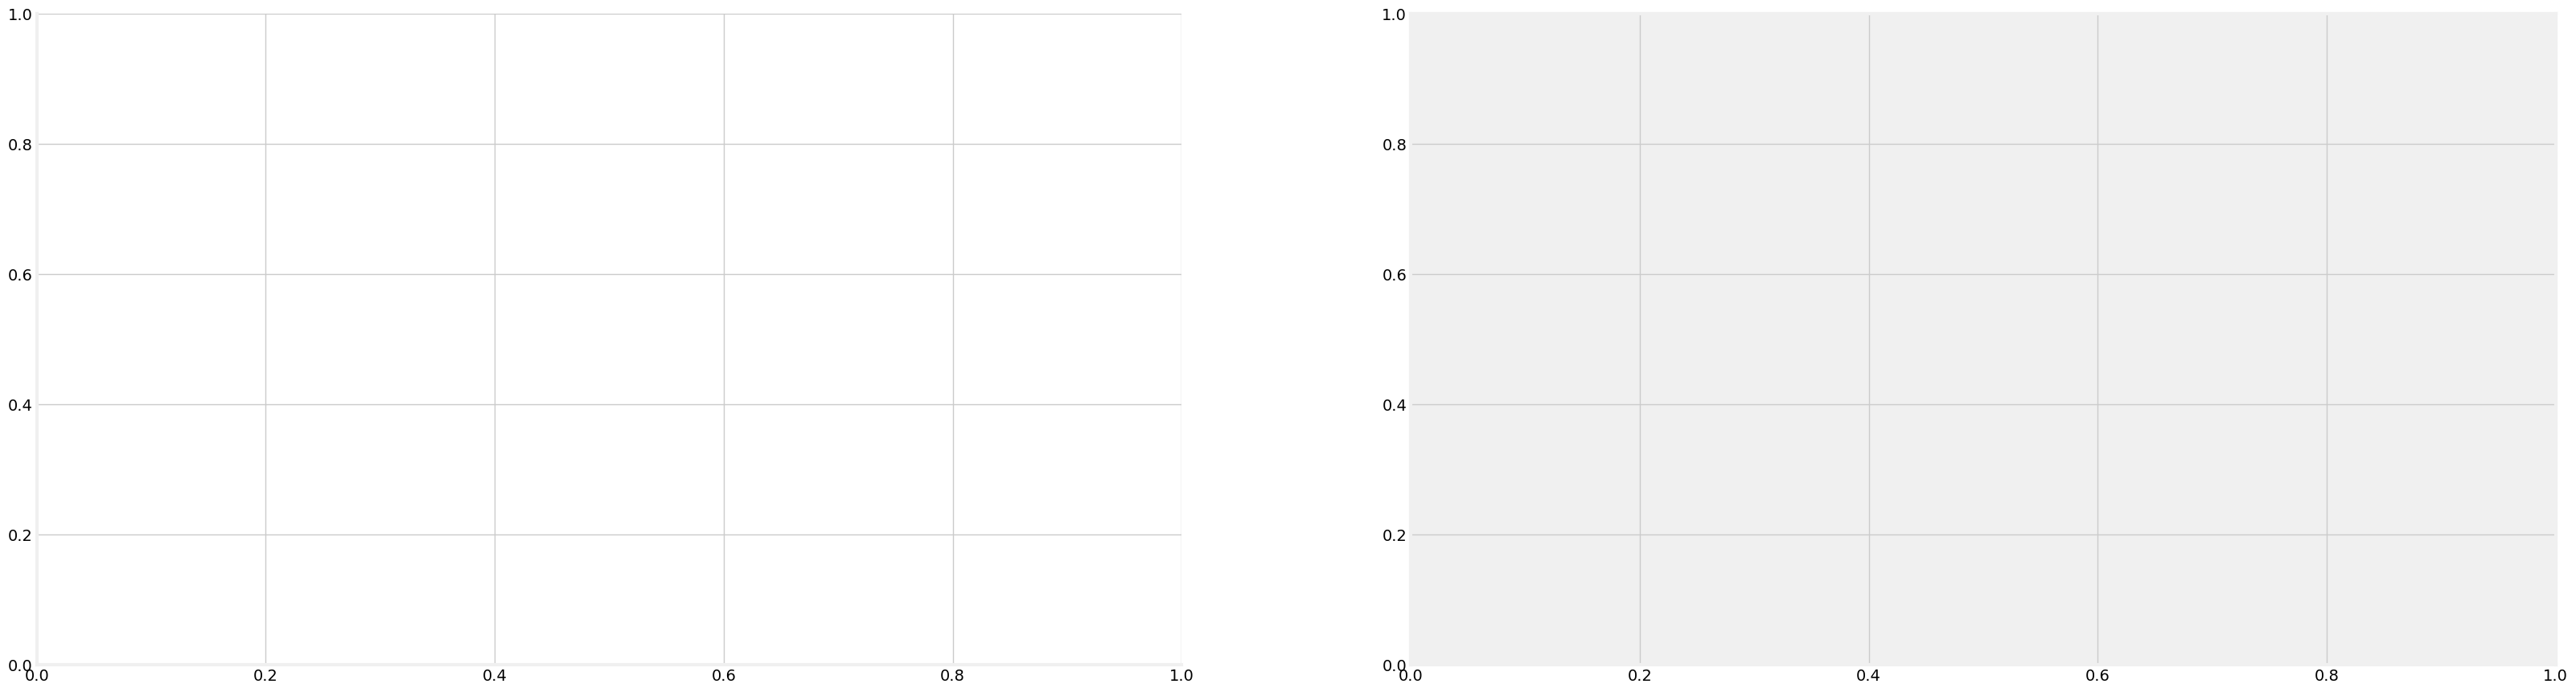

In [ ]:
# Create a main figure with subplots for each task
tasks = ['art', 'celebrity']

fig, axes = plt.subplots(1, len(tasks), figsize=(36, 10))
fig.patch.set_facecolor('white')  # Set figure background to white

change = 'finetuning'
change_str = 'baseline'

for idx, task in enumerate(tasks):

    metric = 'FID'

    plt.style.use('fivethirtyeight')

    df_fig = df[df['change'].str.contains(change_str, na=False)]
    df_fig = df_fig[df_fig['task'] == task]
    df_fig = df_fig[(df_fig['config'].str.contains('erase_cele_10', na=False)) | (df_fig['config'].str.contains('erase_art_100', na=False))]
    df_fig = df_fig[df_fig['metric'] == metric]
    df_fig = df_fig[df_fig['finetune_prompts'].str.contains("_random_concepts_seed0", na=False)]
    df_fig = df_fig[df_fig['type'] == 'mscoco-10k']
    df_fig = df_fig[df_fig['finetune_task'].isin([task, 'none'])]
    df_fig['value'] = df_fig['value'].apply(lambda x: float(x.split('±')[0]) if isinstance(x, str) and '±' in x else float(x))
    # 
    # Filter for 'full' and 'lora' finetune_algo, and 'erase_cele_10' config
    df_fig = df_fig[df_fig['finetune_algo'].isin(['full', 'lora'])]


    grouped = df_fig.groupby(['finetune_algo', 'type'])
    invalid_groups = [name for name, group in grouped if len(group) != 3]
    
    if invalid_groups:
        print("The following groups have an incorrect number of values:")
        for name in invalid_groups:
            group = grouped.get_group(name)
            print(f"Group {name} has {len(group)} values:")
            print(group)

  
    ax = axes[idx]
    ax.set_facecolor('white')  # Set axes background to white
    
    # remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x')
    ax.tick_params(axis='y')
    

    sns.barplot(data=df_fig, x='finetune_algo', y='value', hue='type', ax=ax, capsize=0.5, errwidth=1)

    ax.set_title(f'{task.capitalize()} Task - {x_axis_labels[df_fig["config"].iloc[0]]}', fontsize=32)
    ax.set_xlabel('Fine-tuning Algorithm', fontsize=32)
    ax.set_ylabel(metric_str[metric], fontsize=32)
    ax.tick_params(axis='x', rotation=0)

    # set font size of legend, x axis labels, y axis labels
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=24)
    
    # Increase space between x-axis labels and plot
    ax.tick_params(axis='x', which='major', pad=20)
    ax.tick_params(axis='y', which='major', pad=20)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=24)

    ax.set_facecolor('#E6E6E6')  # Light gray background
    ax.grid(color='white', linestyle='-', linewidth=3, axis='y')
    ax.set_axisbelow(True)  # Ensure grid is behind the bars


    handles, labels = ax.get_legend_handles_labels()
    if idx == 0:  # Only show legend for the first subplot
        ax.legend(handles, labels, title='', loc='upper right', fontsize=24)
    else:
        ax.legend().remove()

plt.tight_layout()
plt.show()

# Save the figure
os.makedirs('figures/finetuning', exist_ok=True)
#fig.savefig(f'figures/finetuning/all_tasks_finetuning_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
print(f"Figure saved as 'figures/finetuning/all_tasks_finetuning_comparison.png'")
    

In [ ]:
change = 'CLIP Distance'
change_str = 'baseline'

for task in ['object', 'art', 'celebrity']:

    metric = metric_map[task]

    plt.style.use('fivethirtyeight')

    df_fig = df[df['change'].str.contains(change_str, na=False)]
    df_fig = df_fig[df_fig['task'] == task]
    df_fig = df_fig[df_fig['metric'] == metric]
    df_fig = df_fig[df_fig['finetune_prompts'].str.contains("clip_", na=False)]
    if task == 'art':
        df_fig['type'] = df_fig['type'].map({"0": "erased", "1": "others"})
    
    df_fig['value'] = df_fig['value'].apply(lambda x: float(x.split('±')[0]) if isinstance(x, str) and '±' in x else float(x))
    
    # Filter for 'full' and 'lora' finetune_algo, and 'erase_cele_10' config
    df_fig = df_fig[df_fig['finetune_algo'].isin(['lora'])]

    grouped = df_fig.groupby(['finetune_prompts', 'type'])
    invalid_groups = [name for name, group in grouped if len(group) != 3]
    
    if invalid_groups:
        print("The following groups have an incorrect number of values:")
        for name in invalid_groups:
            group = grouped.get_group(name)
            print(f"Group {name} has {len(group)} values:")
            print(group)


    fig, ax = plt.subplots(figsize=(12, 6))

    # Sort the DataFrame based on the number at the end of finetune_prompts
    df_fig['prompt_number'] = df_fig['finetune_prompts'].str.extract('(\d+)$').astype(int)
    df_fig['prompt_number'] = df_fig['prompt_number'] + 1
    df_fig = df_fig.sort_values('prompt_number')
    
    custom_order = df_fig['finetune_prompts'].unique()
    ax.set_xlabel('CLIP Distance Tercile')
    ax.set_xticklabels(df_fig['prompt_number'].unique())

    # Plot the data with finetune_algo on x-axis and type as hue
    sns.barplot(data=df_fig, x='finetune_prompts', y='value', hue='type', ax=ax, capsize=0.5, errwidth=1)

    ax.set_title(f'{task.capitalize()} Tasks - {df_fig["config"].iloc[0]}')
    ax.set_ylabel(metric_str[metric])
    ax.tick_params(axis='x', rotation=0)

    ax.legend(title='Type', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

    # Create the 'figures/warmup' directory if it doesn't exist
    import os
    os.makedirs('figures/clip_distance', exist_ok=True)

    # Save the figure
    fig.savefig(f'figures/clip_distance/{task}_clip_distance.png', dpi=300, bbox_inches='tight')
    print(f"Figure saved as 'figures/clip_distance/{task}_clip_distance.png'")

In [ ]:
# Create a main figure with subplots for each task
tasks = ['object', 'celebrity']

fig, axes = plt.subplots(1, len(tasks), figsize=(36, 10))
fig.patch.set_facecolor('white')  # Set figure background to white

change = 'CLIP Distance'
change_str = 'baseline'

for idx, task in enumerate(tasks):

    metric = metric_map[task]

    plt.style.use('fivethirtyeight')

    df_fig = df[df['change'].str.contains(change_str, na=False)]
    df_fig = df_fig[df_fig['task'] == task]
    df_fig = df_fig[df_fig['metric'] == metric]
    df_fig = df_fig[df_fig['type'] != 'mscoco-10k']
    df_fig = df_fig[df_fig['finetune_prompts'].str.contains("clip_", na=False)]
    if task == 'art':
        df_fig['type'] = df_fig['type'].map({"0": "erased", "1": "others"})
    
    df_fig['value'] = df_fig['value'].apply(lambda x: float(x.split('±')[0]) if isinstance(x, str) and '±' in x else float(x))
    
    # Filter for 'full' and 'lora' finetune_algo
    df_fig = df_fig[df_fig['finetune_algo'].isin(['lora'])]

    grouped = df_fig.groupby(['finetune_prompts', 'type'])
    invalid_groups = [name for name, group in grouped if len(group) != 3]
    
    if invalid_groups:
        print("The following groups have an incorrect number of values:")
        for name in invalid_groups:
            group = grouped.get_group(name)
            print(f"Group {name} has {len(group)} values:")
            print(group)

  
    ax = axes[idx]
    ax.set_facecolor('white')  # Set axes background to white
    
    # remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x')
    ax.tick_params(axis='y')
    

    # Sort the DataFrame based on the number at the end of finetune_prompts
    df_fig['prompt_number'] = df_fig['finetune_prompts'].str.extract('(\d+)$').astype(int)
    df_fig['prompt_number'] = df_fig['prompt_number'] + 1
    df_fig = df_fig.sort_values('prompt_number')
    
    custom_order = df_fig['finetune_prompts'].unique()
    ax.set_xlabel('CLIP Distance Tercile')
    ax.set_xticklabels(df_fig['prompt_number'].unique())

    # Plot the data with finetune_algo on x-axis and type as hue
    sns.barplot(data=df_fig, x='finetune_prompts', y='value', hue='type', ax=ax, capsize=0.5, errwidth=1)

    ax.set_title(f'{task.capitalize()} Task - {x_axis_labels[df_fig["config"].iloc[0]]}', fontsize=32)
    ax.tick_params(axis='x', rotation=0)

    # set font size of legend, x axis labels, y axis labels
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=24)
    
    # Increase space between x-axis labels and plot
    ax.tick_params(axis='x', which='major', pad=20)
    ax.tick_params(axis='y', which='major', pad=20)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=24)
    # set font size of ylabel
    ax.set_ylabel(metric_str[metric], fontsize=32)
    ax.set_xlabel('CLIP Distance Tercile', fontsize=32)
    ax.tick_params(axis='x', rotation=0)

    ax.set_facecolor('#E6E6E6')  # Light gray background
    ax.grid(color='white', linestyle='-', linewidth=3, axis='y')
    ax.set_axisbelow(True)  # Ensure grid is behind the bars


    handles, labels = ax.get_legend_handles_labels()
    if idx == 0:  # Only show legend for the first subplot
        ax.legend(handles, labels, title='', loc='upper right', fontsize=24)
    else:
        ax.legend().remove()

plt.tight_layout()
plt.show()

# Save the figure
os.makedirs('figures/clip_distance', exist_ok=True)
fig.savefig(f'figures/clip_distance/all_tasks_clip_distance.png', dpi=300, bbox_inches='tight', facecolor='white')
print(f"Figure saved as 'figures/clip_distance/all_tasks_clip_distance.png'")
    

Empty DataFrame
Columns: [algo, change, task, config, finetune_algo, finetune_task, finetune_prompts, prompts_csv, seed, type, metric, value]
Index: []


IndexError: single positional indexer is out-of-bounds

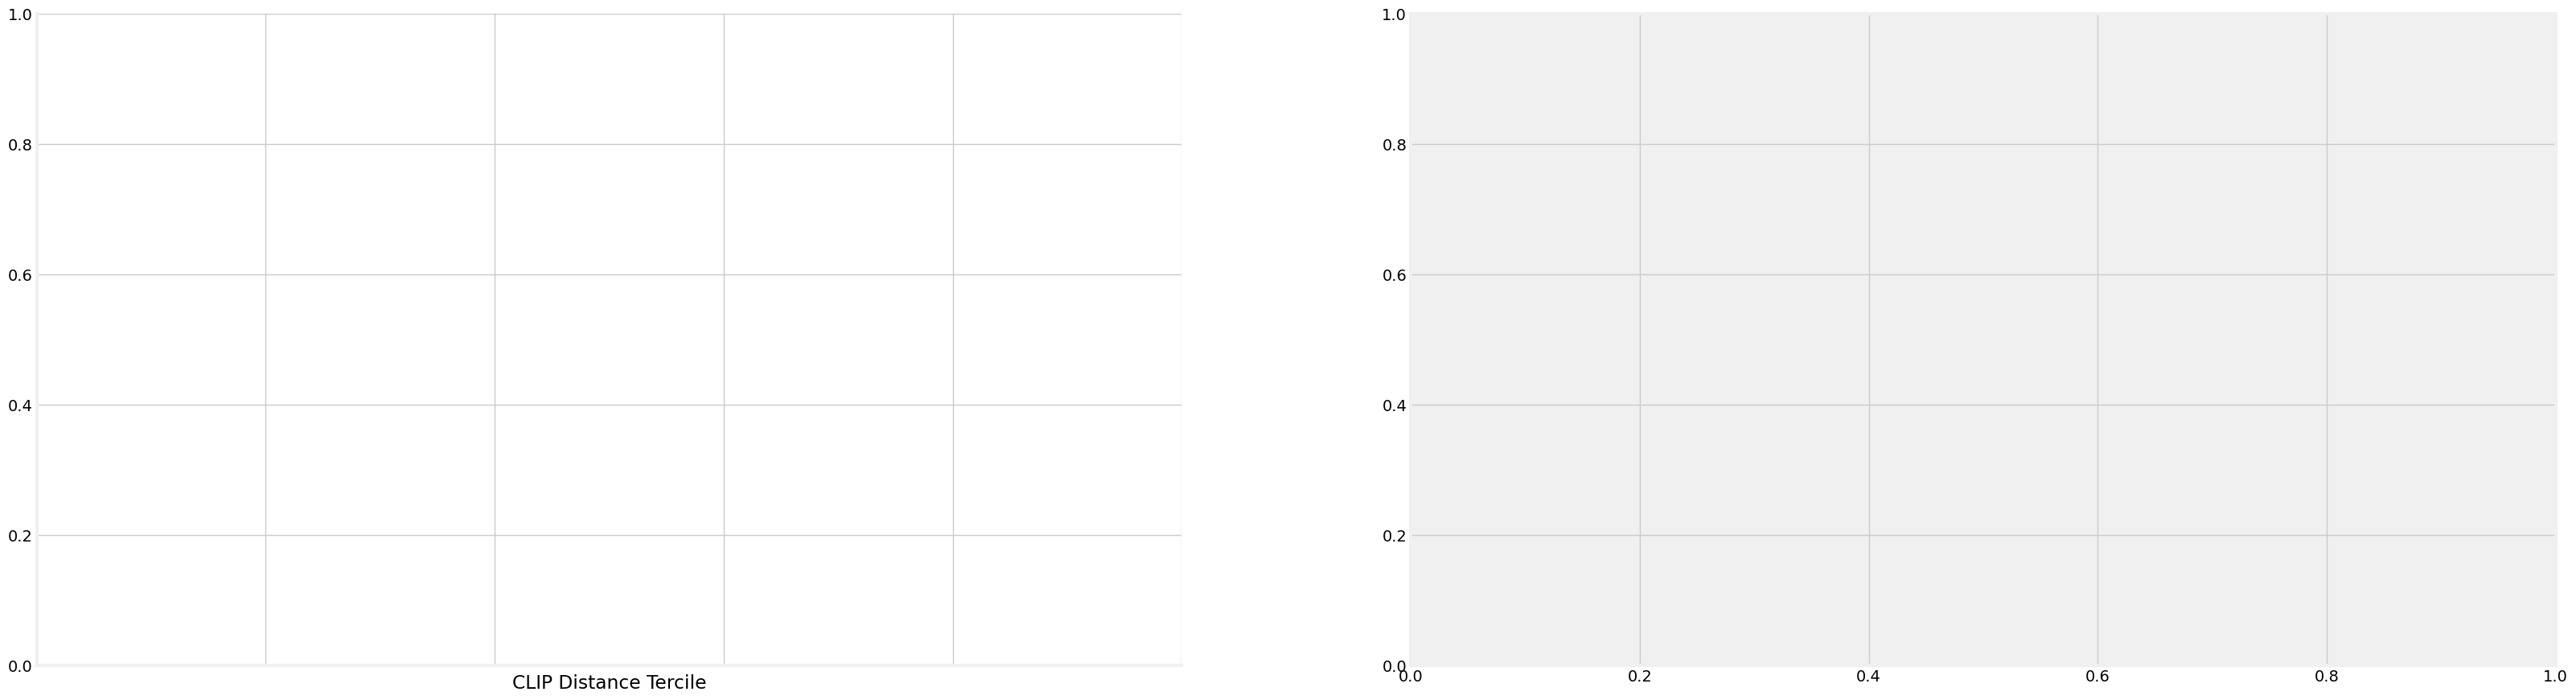

In [ ]:
# Create a main figure with subplots for each task
tasks = ['art', 'celebrity']

fig, axes = plt.subplots(1, len(tasks), figsize=(36, 10))
fig.patch.set_facecolor('white')  # Set figure background to white

change = 'CLIP Distance'
change_str = 'baseline'

for idx, task in enumerate(tasks):

    metric = 'clip_score'

    plt.style.use('fivethirtyeight')

    df_fig = df[df['change'].str.contains(change_str, na=False)]
    df_fig = df_fig[df_fig['task'] == task]
    
    df_fig = df_fig[df_fig['metric'] == metric]
    print(df_fig)
    
    df_fig = df_fig[df_fig['finetune_prompts'].str.contains("clip_", na=False)]
    
    df_fig = df_fig[df_fig['type'] == 'mscoco-10k']
    
    
    df_fig['value'] = df_fig['value'].apply(lambda x: float(x.split('±')[0]) if isinstance(x, str) and '±' in x else float(x))
    
    # Filter for 'full' and 'lora' finetune_algo
    df_fig = df_fig[df_fig['finetune_algo'].isin(['lora'])]

    grouped = df_fig.groupby(['finetune_prompts', 'type'])
    invalid_groups = [name for name, group in grouped if len(group) != 3]
    
    if invalid_groups:
        print("The following groups have an incorrect number of values:")
        for name in invalid_groups:
            group = grouped.get_group(name)
            print(f"Group {name} has {len(group)} values:")
            print(group)

    
  
    ax = axes[idx]
    ax.set_facecolor('white')  # Set axes background to white
    
    # remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x')
    ax.tick_params(axis='y')
    

    # Sort the DataFrame based on the number at the end of finetune_prompts
    df_fig['prompt_number'] = df_fig['finetune_prompts'].str.extract('(\d+)$').astype(int)
    df_fig['prompt_number'] = df_fig['prompt_number'] + 1
    df_fig = df_fig.sort_values('prompt_number')
    
    custom_order = df_fig['finetune_prompts'].unique()
    ax.set_xlabel('CLIP Distance Tercile')
    ax.set_xticklabels(df_fig['prompt_number'].unique())

    # Plot the data with finetune_algo on x-axis and type as hue
    sns.barplot(data=df_fig, x='finetune_prompts', y='value', hue='type', ax=ax, capsize=0.5, errwidth=1)

    ax.set_title(f'{task.capitalize()} Task - {x_axis_labels[df_fig["config"].iloc[0]]}', fontsize=32)
    ax.tick_params(axis='x', rotation=0)

    # set font size of legend, x axis labels, y axis labels
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=24)
    
    # Increase space between x-axis labels and plot
    ax.tick_params(axis='x', which='major', pad=20)
    ax.tick_params(axis='y', which='major', pad=20)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=24)
    # set font size of ylabel
    ax.set_ylabel(metric_str[metric], fontsize=32)
    ax.set_xlabel('CLIP Distance Tercile', fontsize=32)
    ax.tick_params(axis='x', rotation=0)

    ax.set_facecolor('#E6E6E6')  # Light gray background
    ax.grid(color='white', linestyle='-', linewidth=3, axis='y')
    ax.set_axisbelow(True)  # Ensure grid is behind the bars


    handles, labels = ax.get_legend_handles_labels()
    if idx == 0:  # Only show legend for the first subplot
        ax.legend(handles, labels, title='', loc='upper right', fontsize=24)
    else:
        ax.legend().remove()

plt.tight_layout()
plt.show()

# Save the figure
os.makedirs('figures/clip_distance', exist_ok=True)
#fig.savefig(f'figures/clip_distance/all_tasks_clip_distance.png', dpi=300, bbox_inches='tight', facecolor='white')
print(f"Figure saved as 'figures/clip_distance/all_tasks_clip_distance.png'")
    

In [ ]:
change = 'In vs Out of Domain'
change_str = 'baseline'

for task in ['object', 'art', 'celebrity']:

    metric = metric_map[task]

    plt.style.use('fivethirtyeight')

    df_fig = df[df['change'].str.contains(change_str, na=False)]
    df_fig = df_fig[df_fig['task'] == task]
    df_fig = df_fig[df_fig['metric'] == metric]
    df_fig = df_fig[df_fig['finetune_prompts'].str.contains("_random_concepts_seed0", na=False)]
    
    df_fig['value'] = df_fig['value'].apply(lambda x: float(x.split('±')[0]) if isinstance(x, str) and '±' in x else float(x))
    df_fig = df_fig[df_fig['config'].isin(['erase_ship', 'erase_cele_10', 'erase_art_100'])]    # Filter for 'full' and 'lora' finetune_algo, and 'erase_cele_10' config
    df_fig = df_fig[df_fig['finetune_algo'].isin(['lora'])]
    if task == 'art':
        df_fig['type'] = df_fig['type'].map({"0": "erased", "1": "others"})

    grouped = df_fig.groupby(['finetune_task', 'type'])
    invalid_groups = [name for name, group in grouped if len(group) != 3]
    
    if invalid_groups:
        print("The following groups have an incorrect number of values:")
        for name in invalid_groups:
            group = grouped.get_group(name)
            print(f"Group {name} has {len(group)} values:")
            print(group)


    fig, ax = plt.subplots(figsize=(12, 6))

    ax.set_xlabel('Fine-tuning Task')
    

    # Plot the data with finetune_algo on x-axis and type as hue
    sns.barplot(data=df_fig, x='finetune_task', y='value', hue='type', ax=ax, capsize=0.5, errwidth=1)

    ax.set_title(f'{task.capitalize()} Tasks - {df_fig["config"].iloc[0]}')
    ax.set_ylabel(metric_str[metric])
    ax.tick_params(axis='x', rotation=0)
    ax.set_xticklabels(df_fig['finetune_task'].unique())

    ax.legend(title='Type', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

    # Create the 'figures/warmup' directory if it doesn't exist
    import os
    os.makedirs('figures/in_vs_out_domain', exist_ok=True)

    # Save the figure
    fig.savefig(f'figures/in_vs_out_domain/{task}_in_vs_out_domain.png', dpi=300, bbox_inches='tight')
    print(f"Figure saved as 'figures/in_vs_out_domain/{task}_in_vs_out_domain.png'")

In [ ]:
# Create a main figure with subplots for each task
tasks = ['object', 'celebrity']

fig, axes = plt.subplots(1, len(tasks), figsize=(36, 10))
fig.patch.set_facecolor('white')  # Set figure background to white

change = 'In vs Out of Domain'
change_str = 'baseline'

for idx, task in enumerate(tasks):

    metric = metric_map[task]

    plt.style.use('fivethirtyeight')

    df_fig = df[df['change'].str.contains(change_str, na=False)]
    df_fig = df_fig[df_fig['task'] == task]
    df_fig = df_fig[df_fig['metric'] == metric]
    df_fig = df_fig[df_fig['finetune_prompts'].str.contains("_random_concepts_seed0", na=False)]
    df_fig = df_fig[df_fig['type'] != 'mscoco-10k']
    
    df_fig['value'] = df_fig['value'].apply(lambda x: float(x.split('±')[0]) if isinstance(x, str) and '±' in x else float(x))
    df_fig = df_fig[df_fig['config'].isin(['erase_ship', 'erase_cele_10', 'erase_art_100'])]    # Filter for 'full' and 'lora' finetune_algo, and 'erase_cele_10' config
    df_fig = df_fig[df_fig['finetune_algo'].isin(['lora'])]
    if task == 'art':
        df_fig['type'] = df_fig['type'].map({"0": "erased", "1": "others"})

    grouped = df_fig.groupby(['finetune_task', 'type'])
    invalid_groups = [name for name, group in grouped if len(group) != 3]
    
    if invalid_groups:
        print("The following groups have an incorrect number of values:")
        for name in invalid_groups:
            group = grouped.get_group(name)
            print(f"Group {name} has {len(group)} values:")
            print(group)

  
    ax = axes[idx]
    ax.set_facecolor('white')  # Set axes background to white
    
    # remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x')
    ax.tick_params(axis='y')
    

    # Sort the DataFrame based on the number at the end of finetune_prompts
    df_fig['prompt_number'] = df_fig['finetune_prompts'].str.extract('(\d+)$').astype(int)
    df_fig['prompt_number'] = df_fig['prompt_number'] + 1
    df_fig = df_fig.sort_values('prompt_number')
    
    custom_order = df_fig['finetune_prompts'].unique()
    ax.set_xlabel('CLIP Distance Tercile')
    ax.set_xticklabels(df_fig['prompt_number'].unique())

    # Plot the data with finetune_algo on x-axis and type as hue
     # Plot the data with finetune_algo on x-axis and type as hue
    # Add suffix '(baseline)' to the finetune_task that matches the current task
    df_fig['finetune_task'] = df_fig.apply(lambda row: f"{row['finetune_task']} (baseline)" if row['finetune_task'] == task else row['finetune_task'], axis=1)
    
    # Sort the DataFrame so that the baseline appears on the left
    df_fig['is_baseline'] = df_fig['finetune_task'].str.contains('baseline')
    df_fig = df_fig.sort_values('is_baseline', ascending=False)
    
    # Create custom order for x-axis
    custom_order = df_fig['finetune_task'].unique()
    
    # Update x-axis labels
    ax.set_xticklabels(custom_order)
    
    # Define the order for the hue
    hue_order = ['erased', 'others', 'synonyms']
    
    # Plot with specified hue order
    sns.barplot(data=df_fig, x='finetune_task', y='value', hue='type', hue_order=hue_order, ax=ax, capsize=0.5, errwidth=1)

    ax.set_title(f'{task.capitalize()} Task - {x_axis_labels[df_fig["config"].iloc[0]]}', fontsize=32)
    ax.set_ylabel(metric_str[metric])
    ax.tick_params(axis='x', rotation=0)
    ax.set_xticklabels(df_fig['finetune_task'].unique())
    ax.set_ylabel(metric_str[metric], fontsize=32)
    ax.set_xlabel('Fine-tuning Task', fontsize=32)
    ax.tick_params(axis='x', rotation=0)

    # set font size of legend, x axis labels, y axis labels
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=24)
    
    # Increase space between x-axis labels and plot
    ax.tick_params(axis='x', which='major', pad=20)
    ax.tick_params(axis='y', which='major', pad=20)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=24)

    ax.set_facecolor('#E6E6E6')  # Light gray background
    ax.grid(color='white', linestyle='-', linewidth=3, axis='y')
    ax.set_axisbelow(True)  # Ensure grid is behind the bars

    

    handles, labels = ax.get_legend_handles_labels()
    if idx == 0:  # Only show legend for the first subplot
        ax.legend(handles, labels, title='', loc='upper right', fontsize=24)
    else:
        ax.legend().remove()

plt.tight_layout()
plt.show()

# Save the figure
os.makedirs('figures/in_vs_out_domain', exist_ok=True)
fig.savefig(f'figures/in_vs_out_domain/all_tasks_in_vs_out_domain.png', dpi=300, bbox_inches='tight', facecolor='white')
print(f"Figure saved as 'figures/in_vs_out_domain/all_tasks_in_vs_out_domain.png'")
    

In [ ]:
# Create a main figure with subplots for each task
tasks = ['art', 'celebrity']

fig, axes = plt.subplots(1, len(tasks), figsize=(36, 10))
fig.patch.set_facecolor('white')  # Set figure background to white

change = 'In vs Out of Domain'
change_str = 'baseline'

for idx, task in enumerate(tasks):

    metric = 'FID'

    plt.style.use('fivethirtyeight')

    df_fig = df[df['change'].str.contains(change_str, na=False)]
    df_fig = df_fig[df_fig['task'] == task]
    df_fig = df_fig[df_fig['metric'] == metric]
    df_fig = df_fig[df_fig['finetune_prompts'].str.contains("_random_concepts_seed0", na=False)]
    df_fig = df_fig[df_fig['type'] == 'mscoco-10k']
    print(df_fig)
    
    df_fig['value'] = df_fig['value'].apply(lambda x: float(x.split('±')[0]) if isinstance(x, str) and '±' in x else float(x))
    df_fig = df_fig[df_fig['config'].isin(['erase_ship', 'erase_cele_10', 'erase_art_100'])]    # Filter for 'full' and 'lora' finetune_algo, and 'erase_cele_10' config
    df_fig = df_fig[df_fig['finetune_algo'].isin(['lora'])]
    
    grouped = df_fig.groupby(['finetune_task', 'type'])
    invalid_groups = [name for name, group in grouped if len(group) != 3]
    
    if invalid_groups:
        print("The following groups have an incorrect number of values:")
        for name in invalid_groups:
            group = grouped.get_group(name)
            print(f"Group {name} has {len(group)} values:")
            print(group)

  
    ax = axes[idx]
    ax.set_facecolor('white')  # Set axes background to white
    
    # remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x')
    ax.tick_params(axis='y')
    

    # Sort the DataFrame based on the number at the end of finetune_prompts
    df_fig['prompt_number'] = df_fig['finetune_prompts'].str.extract('(\d+)$').astype(int)
    df_fig['prompt_number'] = df_fig['prompt_number'] + 1
    df_fig = df_fig.sort_values('prompt_number')
    
    custom_order = df_fig['finetune_prompts'].unique()
    ax.set_xlabel('CLIP Distance Tercile')
    ax.set_xticklabels(df_fig['prompt_number'].unique())

    # Plot the data with finetune_algo on x-axis and type as hue
     # Plot the data with finetune_algo on x-axis and type as hue
    sns.barplot(data=df_fig, x='finetune_task', y='value', hue='type', ax=ax, capsize=0.5, errwidth=1)

    ax.set_title(f'{task.capitalize()} Task - {x_axis_labels[df_fig["config"].iloc[0]]}', fontsize=32)
    ax.set_ylabel(metric_str[metric])
    ax.tick_params(axis='x', rotation=0)
    ax.set_xticklabels(df_fig['finetune_task'].unique())
    ax.set_ylabel(metric_str[metric], fontsize=32)
    ax.set_xlabel('Fine-tuning Task', fontsize=32)
    ax.tick_params(axis='x', rotation=0)

    # set font size of legend, x axis labels, y axis labels
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=24)
    
    # Increase space between x-axis labels and plot
    ax.tick_params(axis='x', which='major', pad=20)
    ax.tick_params(axis='y', which='major', pad=20)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=24)

    ax.set_facecolor('#E6E6E6')  # Light gray background
    ax.grid(color='white', linestyle='-', linewidth=3, axis='y')
    ax.set_axisbelow(True)  # Ensure grid is behind the bars

    

    handles, labels = ax.get_legend_handles_labels()
    if idx == 0:  # Only show legend for the first subplot
        ax.legend(handles, labels, title='', loc='upper right', fontsize=24)
    else:
        ax.legend().remove()

plt.tight_layout()
plt.show()

# Save the figure
os.makedirs('figures/in_vs_out_domain', exist_ok=True)
#fig.savefig(f'figures/in_vs_out_domain/all_tasks_in_vs_out_domain.png', dpi=300, bbox_inches='tight', facecolor='white')
print(f"Figure saved as 'figures/in_vs_out_domain/all_tasks_in_vs_out_domain.png'")
    

The following groups have an incorrect number of values:
Group ('object', 'erased') has 2 values:
     algo  change    task      config finetune_algo finetune_task  \
545  MACE  object  object  erase_ship          lora        object   
548  MACE  object  object  erase_ship          lora        object   

                 finetune_prompts           prompts_csv seed    type  \
545  object_random_concepts_seed0  object_ship_concepts    1  erased   
548  object_random_concepts_seed0  object_ship_concepts    0  erased   

       metric  value mapping_value  
545  clip_acc   0.22        object  
548  clip_acc   0.24        object  
Group ('object', 'others') has 2 values:
     algo  change    task      config finetune_algo finetune_task  \
546  MACE  object  object  erase_ship          lora        object   
549  MACE  object  object  erase_ship          lora        object   

                 finetune_prompts           prompts_csv seed    type  \
546  object_random_concepts_seed0  object_shi

/tmp/ipykernel_1890417/2485323422.py:73: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.barplot(data=df_fig, x='change', y='value', hue='type', ax=ax, capsize=0.5, errwidth=1)


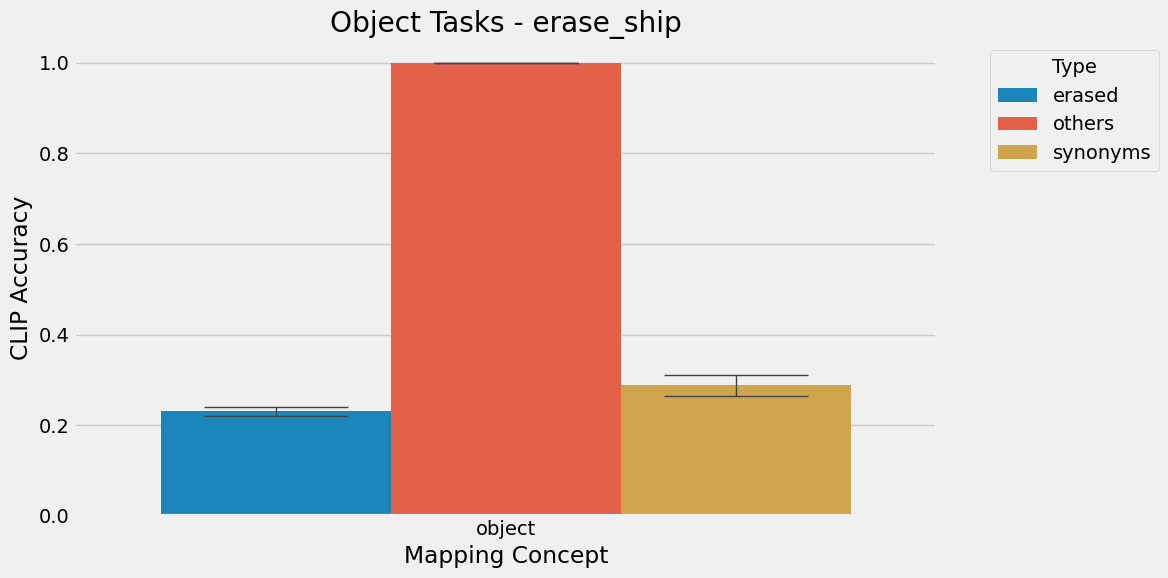

Figure saved as 'figures/mapping_concept/object_mapping_concept.png'


/tmp/ipykernel_1890417/2485323422.py:73: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.barplot(data=df_fig, x='change', y='value', hue='type', ax=ax, capsize=0.5, errwidth=1)


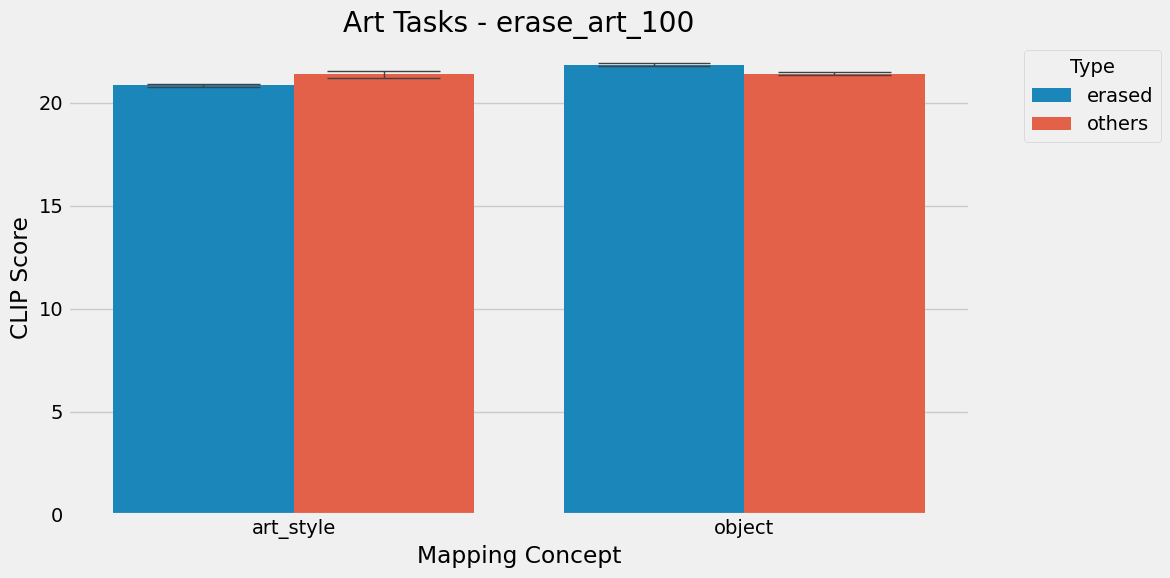

Figure saved as 'figures/mapping_concept/art_mapping_concept.png'
The following groups have an incorrect number of values:
Group ('gender_celebrity', 'others') has 2 values:
     algo            change       task         config finetune_algo  \
420  MACE  gender_celebrity  celebrity  erase_cele_10          lora   
422  MACE  gender_celebrity  celebrity  erase_cele_10          lora   

    finetune_task                 finetune_prompts            prompts_csv  \
420     celebrity  celebrity_random_concepts_seed0  celebrity_10_concepts   
422     celebrity  celebrity_random_concepts_seed0  celebrity_10_concepts   

    seed    type metric     value     mapping_value  
420    0  others    GCD  0.931967  gender_celebrity  
422    2  others    GCD  0.928659  gender_celebrity  
Group ('object', 'erased') has 2 values:
     algo  change       task         config finetune_algo finetune_task  \
621  MACE  object  celebrity  erase_cele_10          lora     celebrity   
623  MACE  object  celebrit

/tmp/ipykernel_1890417/2485323422.py:73: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.barplot(data=df_fig, x='change', y='value', hue='type', ax=ax, capsize=0.5, errwidth=1)


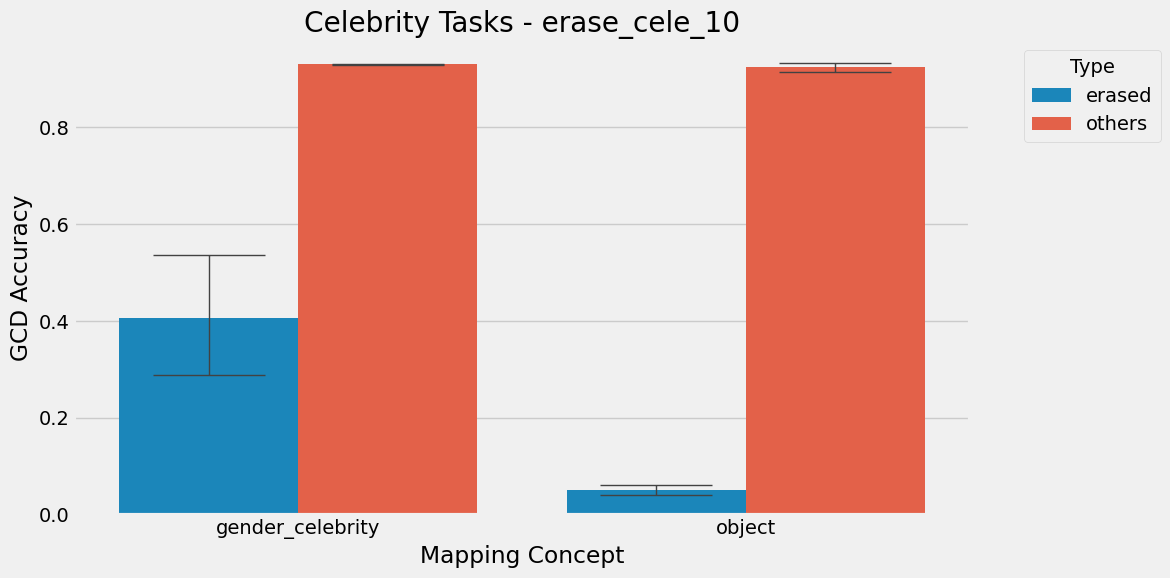

Figure saved as 'figures/mapping_concept/celebrity_mapping_concept.png'


In [ ]:
change = 'Mapping Concept'
change_str = 'mapping='

for task in ['object', 'art', 'celebrity']:

    metric = metric_map[task]

    plt.style.use('fivethirtyeight')

    df_fig = df[(df['change'].str.contains(change_str, na=False)) | (df['change'] == 'baseline')]
    df_fig = df_fig[df_fig['task'] == task]
    df_fig = df_fig[df_fig['metric'] == metric]
    df_fig = df_fig[df_fig['finetune_prompts'].str.contains("_random_concepts_seed0", na=False)]
    df_fig = df_fig[df_fig['finetune_task'] == task]
    
    df_fig['value'] = df_fig['value'].apply(lambda x: float(x.split('±')[0]) if isinstance(x, str) and '±' in x else float(x))
    df_fig['config'] = df_fig['config'].apply(lambda x: 'erase_ship' if x.startswith('erase_ship_') else
                                              ('erase_cele_10' if x.startswith('erase_cele_10_') else
                                               ('erase_art_100' if x.startswith('erase_art_100_') else x)))
    
    df_fig['mapping_value'] = df_fig['change'].apply(lambda x: x.split('=')[-1] if '=' in x else 'baseline')
    
    df_fig = df_fig.sort_values('mapping_value')
    
    df_fig['change'] = df_fig['mapping_value']
    df_fig = df_fig[df_fig['config'].isin(['erase_ship', 'erase_cele_10', 'erase_art_100'])]    # Filter for 'full' and 'lora' finetune_algo, and 'erase_cele_10' config
    df_fig = df_fig[df_fig['finetune_algo'].isin(['lora'])]
    if task == 'art':
        df_fig['type'] = df_fig['type'].map({"0": "erased", "1": "others"})
    
    grouped = df_fig.groupby(['change', 'type'])
    invalid_groups = [name for name, group in grouped if len(group) != 3]
    
    if invalid_groups:
        print("The following groups have an incorrect number of values:")
        for name in invalid_groups:
            group = grouped.get_group(name)
            print(f"Group {name} has {len(group)} values:")
            print(group)

    # Create a mapping for baseline concepts
    baseline_mapping = {
        'celebrity': 'a person',
        'art': 'art',
        'object': {
            'erase_ship': 'ground',
            'erase_bird': 'street',
            'erase_automobile': 'sky'
        }
    }

    # Function to extract mapping concept or use baseline
    def get_mapping_concept(change, task, config):
        if change == 'baseline':
            if task == 'object':
                return baseline_mapping[task][config]
            else:
                return baseline_mapping[task]   
        else:
            return change.split('=')[-1]

    # Apply the function to create a new column for x-axis labels
    df_fig['mapping_concept'] = df_fig.apply(lambda row: get_mapping_concept(row['change'], task, row['config']), axis=1)

    # Sort the dataframe by the new mapping_concept column
    df_fig = df_fig.sort_values('mapping_concept')

    # Update the 'change' column to use the new mapping_concept
    df_fig['change'] = df_fig['mapping_concept']
    fig, ax = plt.subplots(figsize=(12, 6))

    ax.set_xlabel('Mapping Concept')
    sns.barplot(data=df_fig, x='change', y='value', hue='type', ax=ax, capsize=0.5, errwidth=1)

    ax.set_title(f'{task.capitalize()} Tasks - {df_fig["config"].iloc[0]}')
    ax.set_ylabel(metric_str[metric])
    ax.tick_params(axis='x', rotation=0)

    ax.legend(title='Type', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

    # Create the 'figures/warmup' directory if it doesn't exist
    import os
    os.makedirs('figures/mapping_concept', exist_ok=True)

    # Save the figure
    fig.savefig(f'figures/mapping_concept/{task}_mapping_concept.png', dpi=300, bbox_inches='tight')
    print(f"Figure saved as 'figures/mapping_concept/{task}_mapping_concept.png'")

The following groups have an incorrect number of values:
Group ('object', 'erased') has 2 values:
     algo  change    task      config finetune_algo finetune_task  \
545  MACE  object  object  erase_ship          lora        object   
548  MACE  object  object  erase_ship          lora        object   

                 finetune_prompts           prompts_csv seed    type  \
545  object_random_concepts_seed0  object_ship_concepts    1  erased   
548  object_random_concepts_seed0  object_ship_concepts    0  erased   

       metric  value mapping_value  
545  clip_acc   0.22        object  
548  clip_acc   0.24        object  
Group ('object', 'others') has 2 values:
     algo  change    task      config finetune_algo finetune_task  \
546  MACE  object  object  erase_ship          lora        object   
549  MACE  object  object  erase_ship          lora        object   

                 finetune_prompts           prompts_csv seed    type  \
546  object_random_concepts_seed0  object_shi

/tmp/ipykernel_1890417/3251222031.py:102: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.barplot(data=df_fig, x='change', y='value', hue='type', ax=ax, capsize=0.5, errwidth=1)
/tmp/ipykernel_1890417/3251222031.py:111: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=24)
/tmp/ipykernel_1890417/3251222031.py:119: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=24)
/tmp/ipykernel_1890417/3251222031.py:102: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.barplot(data=df_fig, x='change', y='value', hue='type', ax=ax, capsize=0.5, errwidth=1)
/tmp/ipykernel

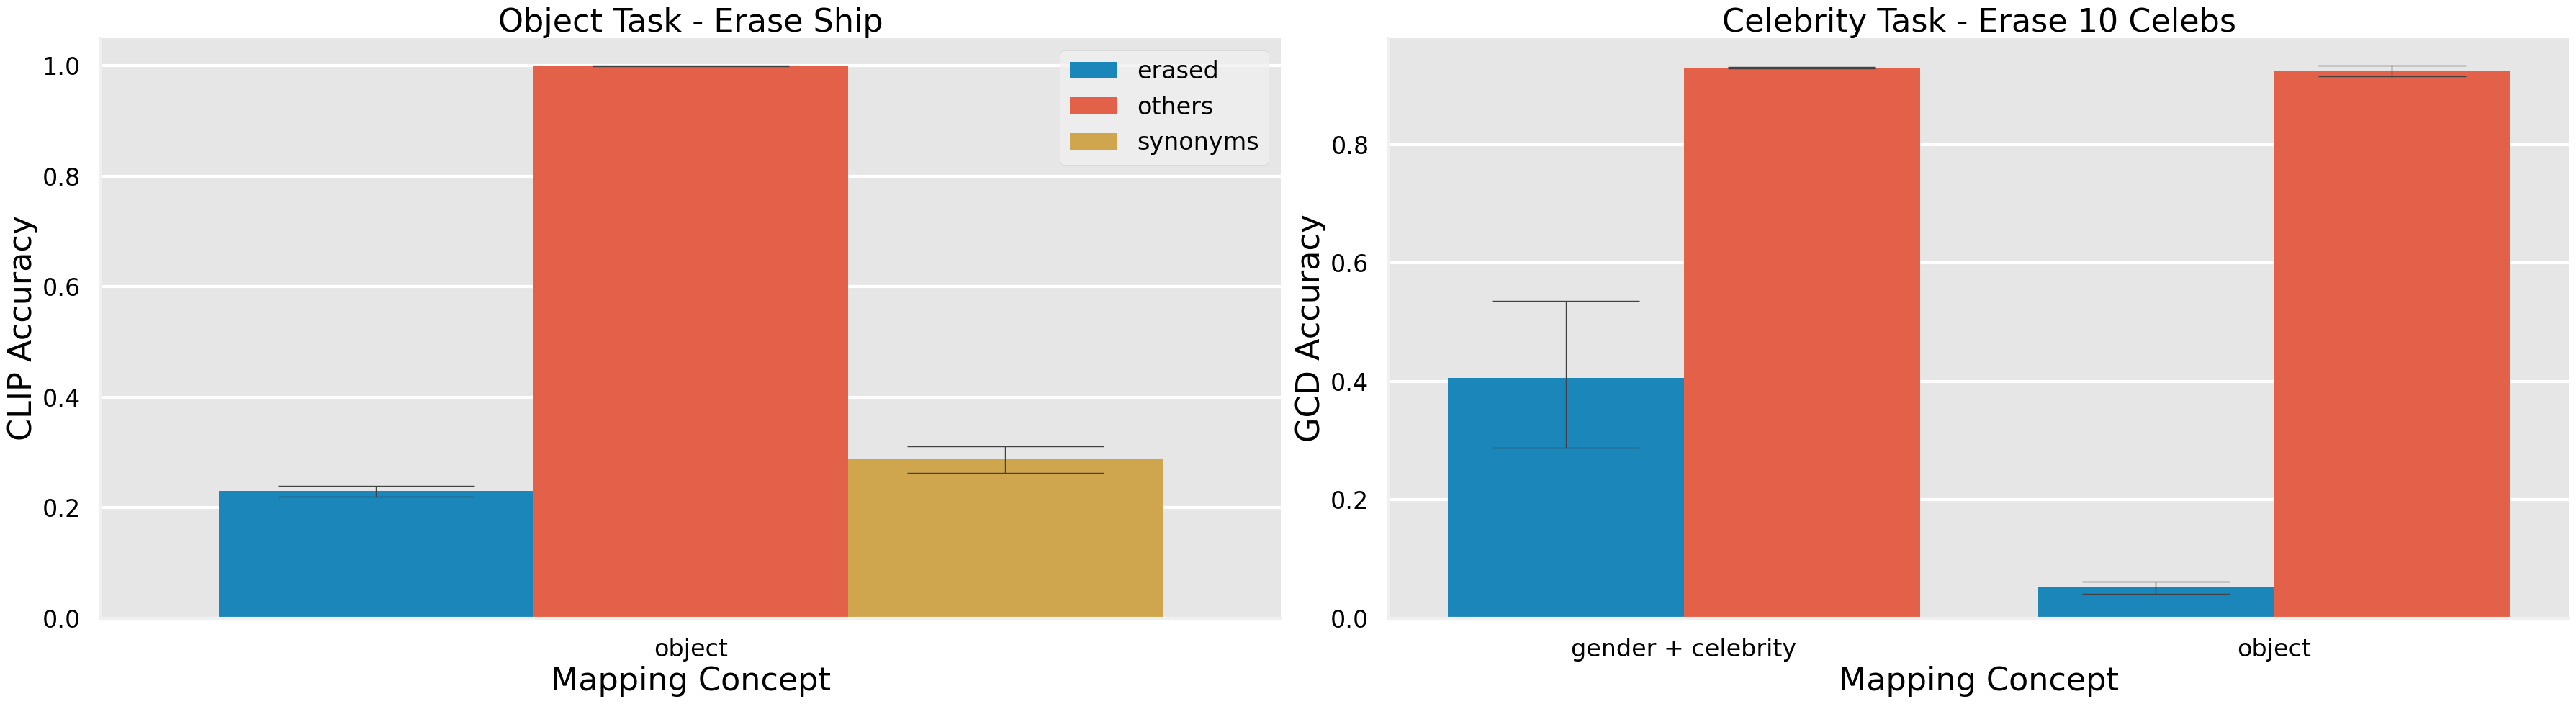

Figure saved as 'figures/mapping_concept/all_tasks_mapping_concept.png'


In [ ]:
# Create a main figure with subplots for each task
tasks = ['object', 'celebrity']
x_axis_labels = {
    'erase_ship': 'Erase Ship',
    'erase_bird': 'Erase Bird',
    'erase_automobile': 'Erase Automobile',
    'erase_cele_1': 'Erase 1 Celeb',
    'erase_cele_5': 'Erase 5 Celebs',
    'erase_cele_10': 'Erase 10 Celebs',
    'erase_cele_100': 'Erase 100 Celebs'
}

fig, axes = plt.subplots(1, len(tasks), figsize=(36, 10))
fig.patch.set_facecolor('white')  # Set figure background to white

change = 'Mapping Concept'
change_str = 'mapping='

for idx, task in enumerate(tasks):

    metric = metric_map[task]

    plt.style.use('fivethirtyeight')

    df_fig = df[(df['change'].str.contains(change_str, na=False)) | (df['change'] == 'baseline')]
    df_fig = df_fig[df_fig['task'] == task]
    df_fig = df_fig[df_fig['metric'] == metric]
    df_fig = df_fig[df_fig['finetune_prompts'].str.contains("_random_concepts_seed0", na=False)]
    df_fig = df_fig[df_fig['finetune_task'] == task]
    df_fig = df_fig[df_fig['type'] != 'mscoco-10k']
    
    df_fig['value'] = df_fig['value'].apply(lambda x: float(x.split('±')[0]) if isinstance(x, str) and '±' in x else float(x))
    df_fig['config'] = df_fig['config'].apply(lambda x: 'erase_ship' if x.startswith('erase_ship_') else
                                              ('erase_cele_10' if x.startswith('erase_cele_10_') else
                                               ('erase_art_100' if x.startswith('erase_art_100_') else x)))
    
    df_fig['mapping_value'] = df_fig['change'].apply(lambda x: x.split('=')[-1] if '=' in x else 'baseline')
    
    df_fig = df_fig.sort_values('mapping_value')
    
    df_fig['change'] = df_fig['mapping_value']
    df_fig = df_fig[df_fig['config'].isin(['erase_ship', 'erase_cele_10', 'erase_art_100'])]    # Filter for 'full' and 'lora' finetune_algo, and 'erase_cele_10' config
    df_fig = df_fig[df_fig['finetune_algo'].isin(['lora'])]
    if task == 'art':
        df_fig['type'] = df_fig['type'].map({"0": "erased", "1": "others"})
    
    grouped = df_fig.groupby(['change', 'type'])
    invalid_groups = [name for name, group in grouped if len(group) != 3]
    
    if invalid_groups:
        print("The following groups have an incorrect number of values:")
        for name in invalid_groups:
            group = grouped.get_group(name)
            print(f"Group {name} has {len(group)} values:")
            print(group)

    # Create a mapping for baseline concepts
    baseline_mapping = {
        'celebrity': 'a person (baseline)',
        'art': 'art (baseline)',
        'object': {
            'erase_ship': 'ground (baseline)',
            'erase_bird': 'street (baseline)',
            'erase_automobile': 'sky (baseline)'
        }
    }

    # Function to extract mapping concept or use baseline
    def get_mapping_concept(change, task, config):
        if change == 'baseline':
            if task == 'object':
                return baseline_mapping[task][config]
            else:
                return baseline_mapping[task]   
        elif 'gender_celebrity' in change:
            return 'gender + celebrity'
        else:
            return change.split('=')[-1]

    # Apply the function to create a new column for x-axis labels
    df_fig['mapping_concept'] = df_fig.apply(lambda row: get_mapping_concept(row['change'], task, row['config']), axis=1)

    # Sort the dataframe by the new mapping_concept column
    df_fig = df_fig.sort_values('mapping_concept')

    # Update the 'change' column to use the new mapping_concept
    df_fig['change'] = df_fig['mapping_concept']

  
    ax = axes[idx]
    ax.set_facecolor('white')  # Set axes background to white
    
    # remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x')
    ax.tick_params(axis='y')
    

    ax.set_xlabel('Mapping Concept', fontsize=32)
    
    sns.barplot(data=df_fig, x='change', y='value', hue='type', ax=ax, capsize=0.5, errwidth=1)

    ax.set_title(f'{task.capitalize()} Task - {x_axis_labels[df_fig["config"].iloc[0]]}', fontsize=32)
    ax.set_ylabel(metric_str[metric])
    ax.tick_params(axis='x', rotation=0)
    ax.set_ylabel(metric_str[metric], fontsize=32)


    # set font size of legend, x axis labels, y axis labels
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=24)
    
    # Increase space between x-axis labels and plot
    ax.tick_params(axis='x', which='major', pad=20)
    ax.tick_params(axis='y', which='major', pad=20)
    # Move y-axis label away from the y-axis
    #ax.yaxis.set_label_coords(-0.05, 0.5)
    #plt.subplots_adjust(wspace=0.5)  # Adjust this value as needed
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=24)

    # Set gray background with white grid lines
    ax.set_facecolor('#E6E6E6')  # Light gray background
    ax.grid(color='white', linestyle='-', linewidth=3, axis='y')
    ax.set_axisbelow(True)  # Ensure grid is behind the bars

    handles, labels = ax.get_legend_handles_labels()
    if idx == 0:  # Only show legend for the first subplot
        ax.legend(handles, labels, title='', loc='upper right', fontsize=24)
    else:
        ax.legend().remove()

plt.tight_layout()
plt.show()

# Save the figure
os.makedirs('figures/mapping_concept', exist_ok=True)
fig.savefig(f'figures/mapping_concept/all_tasks_mapping_concept.png', dpi=300, bbox_inches='tight', facecolor='white')
print(f"Figure saved as 'figures/mapping_concept/all_tasks_mapping_concept.png'")
    

ValueError: Cannot set a DataFrame with multiple columns to the single column mapping_concept

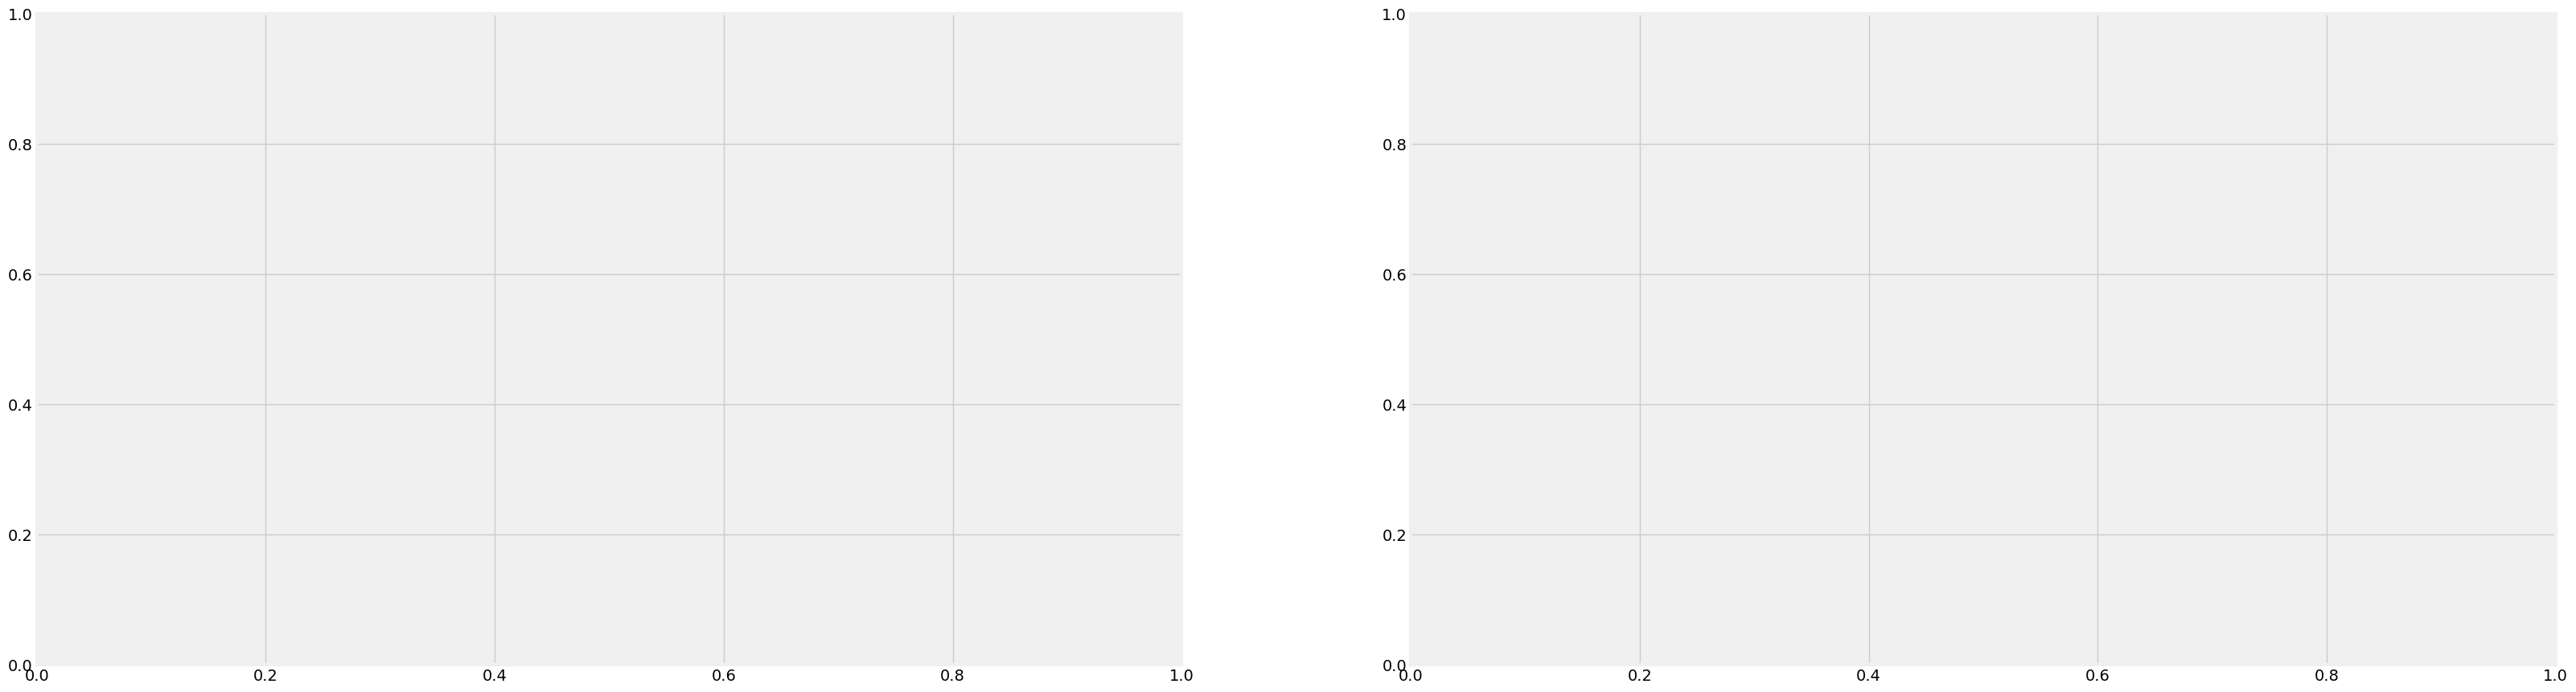

In [ ]:
# Create a main figure with subplots for each task
tasks = ['art', 'celebrity']


fig, axes = plt.subplots(1, len(tasks), figsize=(36, 10))
fig.patch.set_facecolor('white')  # Set figure background to white

change = 'Mapping Concept'
change_str = 'mapping='

for idx, task in enumerate(tasks):

    metric = 'FID'

    plt.style.use('fivethirtyeight')

    df_fig = df[(df['change'].str.contains(change_str, na=False)) | (df['change'] == 'baseline')]
    df_fig = df_fig[df_fig['task'] == task]
    df_fig = df_fig[df_fig['metric'] == metric]
    df_fig = df_fig[df_fig['finetune_prompts'].str.contains("_random_concepts_seed0", na=False)]
    df_fig = df_fig[df_fig['finetune_task'] == task]
    df_fig = df_fig[df_fig['type'] == 'mscoco-10k']
    
    df_fig['value'] = df_fig['value'].apply(lambda x: float(x.split('±')[0]) if isinstance(x, str) and '±' in x else float(x))
    df_fig['config'] = df_fig['config'].apply(lambda x: 'erase_ship' if x.startswith('erase_ship_') else
                                              ('erase_cele_10' if x.startswith('erase_cele_10_') else
                                               ('erase_art_100' if x.startswith('erase_art_100_') else x)))
    
    df_fig['mapping_value'] = df_fig['change'].apply(lambda x: x.split('=')[-1] if '=' in x else 'baseline')
    
    df_fig = df_fig.sort_values('mapping_value')
    
    df_fig['change'] = df_fig['mapping_value']
    df_fig = df_fig[df_fig['config'].isin(['erase_ship', 'erase_cele_10', 'erase_art_100'])]    # Filter for 'full' and 'lora' finetune_algo, and 'erase_cele_10' config
    df_fig = df_fig[df_fig['finetune_algo'].isin(['lora'])]
    
    grouped = df_fig.groupby(['change', 'type'])
    invalid_groups = [name for name, group in grouped if len(group) != 3]
    
    if invalid_groups:
        print("The following groups have an incorrect number of values:")
        for name in invalid_groups:
            group = grouped.get_group(name)
            print(f"Group {name} has {len(group)} values:")
            print(group)

    # Create a mapping for baseline concepts
    baseline_mapping = {
        'celebrity': 'a person (baseline)',
        'art': 'art (baseline)',
        'object': {
            'erase_ship': 'ground (baseline)',
            'erase_bird': 'street (baseline)',
            'erase_automobile': 'sky (baseline)'
        }
    }

    # Function to extract mapping concept or use baseline
    def get_mapping_concept(change, task, config):
        if change == 'baseline':
            if task == 'object':
                return baseline_mapping[task][config]
            else:
                return baseline_mapping[task]   
        elif 'gender_celebrity' in change:
            return 'gender + celebrity'
        else:
            return change.split('=')[-1]

    # Apply the function to create a new column for x-axis labels
    df_fig['mapping_concept'] = df_fig.apply(lambda row: get_mapping_concept(row['change'], task, row['config']), axis=1)

    # Sort the dataframe by the new mapping_concept column
    df_fig = df_fig.sort_values('mapping_concept')

    # Update the 'change' column to use the new mapping_concept
    df_fig['change'] = df_fig['mapping_concept']

  
    ax = axes[idx]
    ax.set_facecolor('white')  # Set axes background to white
    
    # remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x')
    ax.tick_params(axis='y')
    

    ax.set_xlabel('Mapping Concept', fontsize=32)
    
    sns.barplot(data=df_fig, x='change', y='value', hue='type', ax=ax, capsize=0.5, errwidth=1)

    ax.set_title(f'{task.capitalize()} Task - {x_axis_labels[df_fig["config"].iloc[0]]}', fontsize=32)
    ax.set_ylabel(metric_str[metric])
    ax.tick_params(axis='x', rotation=0)
    ax.set_ylabel(metric_str[metric], fontsize=32)


    # set font size of legend, x axis labels, y axis labels
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=24)
    
    # Increase space between x-axis labels and plot
    ax.tick_params(axis='x', which='major', pad=20)
    ax.tick_params(axis='y', which='major', pad=20)
    # Move y-axis label away from the y-axis
    #ax.yaxis.set_label_coords(-0.05, 0.5)
    #plt.subplots_adjust(wspace=0.5)  # Adjust this value as needed
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=24)

    # Set gray background with white grid lines
    ax.set_facecolor('#E6E6E6')  # Light gray background
    ax.grid(color='white', linestyle='-', linewidth=3, axis='y')
    ax.set_axisbelow(True)  # Ensure grid is behind the bars

    handles, labels = ax.get_legend_handles_labels()
    if idx == 0:  # Only show legend for the first subplot
        ax.legend(handles, labels, title='', loc='upper right', fontsize=24)
    else:
        ax.legend().remove()

plt.tight_layout()
plt.show()

# Save the figure
os.makedirs('figures/mapping_concept', exist_ok=True)
#fig.savefig(f'figures/mapping_concept/all_tasks_mapping_concept.png', dpi=300, bbox_inches='tight', facecolor='white')
print(f"Figure saved as 'figures/mapping_concept/all_tasks_mapping_concept.png'")
    

In [ ]:
import matplotlib.pyplot as plt

prefix = '/data/healthy-ml/scratch/vinithms/projects/MACE-Update/experiments/MACE/'
celebrity_paths = [prefix + 'baseline_celebrity_erase_cele_1', prefix + 'baseline_celebrity_erase_cele_5', prefix + 'baseline_celebrity_erase_cele_10', prefix + 'baseline_celebrity_erase_cele_100']
celebrity_tasks = ['Erase 1 Celeb', 'Erase 5 Celebs', 'Erase 10 Celebs', 'Erase 100 Celebs']
celebrity_prompts = list(zip(celebrity_paths, ['A portrait of Melania Trump', 'A portrait of Andrew Garfield', 'A portrait of Angelina Jolie', 'A portrait of Barack Obama']))
#celebrity_prompts = list(zip(celebrity_paths, ['A sketch of Melania Trump', 'A sketch of Andrew Garfield', 'A sketch of Angelina Jolie', 'A sketch of Barack Obama']))
#celebrity_prompts = list(zip(celebrity_paths, ['An oil painting of Melania Trump', 'An oil painting of Andrew Garfield', 'An oil painting of Angelina Jolie', 'An oil painting of Barack Obama']))
celebrity_sd_prompts = list(zip(celebrity_paths, ['a-photo-of-the-melania-trump', 'a-photo-of-the-andrew-garfield', 'a-photo-of-the-angelina-jolie', 'a-photo-of-the-barack-obama']))
celebrity_names = ['Melania Trump', 'Andrew Garfield', 'Angelina Jolie', 'Barack Obama']

#art_paths = [prefix + 'baseline_art_erase_art_100', prefix + 'baseline_art_erase_art_100_seed1', prefix + 'baseline_art_erase_art_100_seed2', prefix + 'baseline_art_erase_art_100_seed3']
object_paths = [prefix + 'baseline_object_erase_ship', prefix + 'baseline_object_erase_bird', prefix + 'baseline_object_erase_automobile']
object_tasks = ['Erase Ship', 'Erase Bird', 'Erase Automobile']
object_prompts = list(zip(object_paths, ['A photo of the ship', 'A photo of the bird', 'A photo of the automobile']))

art_paths = [prefix + 'baseline_art_erase_art_100']
art_tasks = ['Erase 100 Artists']
art_prompts = list(zip(art_paths, ['Image in the style of Claude Monet', 'Image in the style of Camille Pissarro', 'Image in the style of Caspar David Friedrich', 'Image in the style of Chuck Close', 'Image in the style of Cindy Sherman']))


def get_sd_path(celebrity_name):
    return '/data/healthy-ml/scratch/vinithms/projects/MACE-Update/data/unlearning/100cele/' + celebrity_name.lower().replace(' ', '\\ ') + '/'

def get_baseline_path(task, path):
    if task == 'art':
        return path + 'inference/art_100_concepts/0/'
    else:
        base = path + '/0/inference/' + task + '_' + path.split('_')[-1] + '_concepts/'
        return os.path.join(base, 'erased')
def get_finetuned_path(task, path):
    if task == 'art':
        
    base = path + '/0/finetune/lora/' + task + '_' + task + '_random_concepts_seed0/inference/' + task + '_' + path.split('_')[-1] + '_concepts/'
    return os.path.join(base, 'erased')

import matplotlib.pyplot as plt
import os
from PIL import Image
import glob
    

def get_first_image(path, prompt):
    matching_paths = glob.glob(path)
    path = matching_paths[0]
    if os.path.exists(path):
        images = [f for f in os.listdir(path) if f.endswith(('.png', '.jpg', '.jpeg'))]
        print(path, len(images))
        for image in images:
            if prompt.lower() in image.lower():
                return Image.open(os.path.join(path, image))
    else:
        print(path, 'does not exist')
    return None



In [ ]:

fig, axs = plt.subplots(2, 4, figsize=(20, 10))
#fig.suptitle('Celebrity Images: Before and After Finetuning', fontsize=16)

for idx, path in enumerate(celebrity_paths):
    #sd_image = get_first_image(get_sd_path(celebrity_names[idx]), celebrity_sd_prompts[idx][1])
    baseline_img = get_first_image(get_baseline_path('celebrity', path), celebrity_prompts[idx][1])
    finetuned_img = get_first_image(get_finetuned_path('celebrity', path), celebrity_prompts[idx][1])
    # if sd_image:
    #     axs[0, idx].imshow(sd_image)
    #     axs[0, idx].axis('off')
    # else:
    #     axs[0, idx].text(0.5, 0.5, 'Image not found', ha='center', va='center')
    if baseline_img:
        axs[0, idx].imshow(baseline_img)
        axs[0, idx].axis('off')
    else:
        axs[0, idx].text(0.5, 0.5, 'Image not found', ha='center', va='center')
    
    if finetuned_img:
        axs[1, idx].imshow(finetuned_img)
        axs[1, idx].axis('off')
    else:
        axs[1, idx].text(0.5, 0.5, 'Image not found', ha='center', va='center')

    axs[0, idx].set_title(f'{celebrity_tasks[idx]}', fontsize=24)
    
for idx, prompt in enumerate(celebrity_prompts):
    fig.text(1.0/(2 * len(celebrity_prompts)) + idx * 1.0/len(celebrity_prompts), -0.01, prompt[1], ha='center', va='center', fontsize=24, wrap=True)

# Add row labels
fig.text(-.01, 0.75, 'Before Finetuning', va='center', rotation='vertical', fontsize=24)
fig.text(-.01, 0.25, 'After Finetuning', va='center', rotation='vertical', fontsize=24)

plt.tight_layout()
plt.show()

# Save the figure
os.makedirs('figures/qualitative', exist_ok=True)
fig.savefig('figures/qualitative/celeb_qualitative_warmup.png', dpi=600, bbox_inches='tight')
print("Figure saved as 'figures/qualitative/celeb_qualitative_warmup.png'")

In [ ]:
fig, axs = plt.subplots(2, 3, figsize=(20, 10))
#fig.suptitle('Celebrity Images: Before and After Finetuning', fontsize=16)

for idx, path in enumerate(object_paths):
    #sd_image = get_first_image(get_sd_path(celebrity_names[idx]), celebrity_sd_prompts[idx][1])
    baseline_img = get_first_image(get_baseline_path('object', path), object_prompts[idx][1])
    finetuned_img = get_first_image(get_finetuned_path('object', path), object_prompts[idx][1])
    # if sd_image:
    #     axs[0, idx].imshow(sd_image)
    #     axs[0, idx].axis('off')
    # else:
    #     axs[0, idx].text(0.5, 0.5, 'Image not found', ha='center', va='center')
    if baseline_img:
        axs[0, idx].imshow(baseline_img)
        axs[0, idx].axis('off')
    else:
        axs[0, idx].text(0.5, 0.5, 'Image not found', ha='center', va='center')
    
    if finetuned_img:
        axs[1, idx].imshow(finetuned_img)
        axs[1, idx].axis('off')
    else:
        axs[1, idx].text(0.5, 0.5, 'Image not found', ha='center', va='center')

    axs[0, idx].set_title(f'{object_tasks[idx]}', fontsize=24)
    
for idx, prompt in enumerate(object_prompts):
    fig.text(1.0/(2 * len(object_prompts)) + idx * 1.0/len(object_prompts), -0.01, prompt[1], ha='center', va='center', fontsize=24, wrap=True)

# Add row labels
fig.text(0.01, 0.75, 'Before Finetuning', va='center', rotation='vertical', fontsize=24)
fig.text(0.01, 0.25, 'After Finetuning', va='center', rotation='vertical', fontsize=24)

plt.tight_layout()
plt.show()

# Save the figure
os.makedirs('figures/qualitative', exist_ok=True)
fig.savefig('figures/qualitative/object_qualitative_warmup.png', dpi=600, bbox_inches='tight')
print("Figure saved as 'figures/qualitative/object_qualitative_warmup.png'")

In [ ]:
fig, axs = plt.subplots(2, 3, figsize=(20, 10))
#fig.suptitle('Celebrity Images: Before and After Finetuning', fontsize=16)

for idx, path in enumerate(art_paths):
    #sd_image = get_first_image(get_sd_path(celebrity_names[idx]), celebrity_sd_prompts[idx][1])
    baseline_img = get_first_image(get_baseline_path('art', path), art_prompts[idx][1])
    finetuned_img = get_first_image(get_finetuned_path('art', path), art_prompts[idx][1])
    # if sd_image:
    #     axs[0, idx].imshow(sd_image)
    #     axs[0, idx].axis('off')
    # else:
    #     axs[0, idx].text(0.5, 0.5, 'Image not found', ha='center', va='center')
    if baseline_img:
        axs[0, idx].imshow(baseline_img)
        axs[0, idx].axis('off')
    else:
        axs[0, idx].text(0.5, 0.5, 'Image not found', ha='center', va='center')
    
    if finetuned_img:
        axs[1, idx].imshow(finetuned_img)
        axs[1, idx].axis('off')
    else:
        axs[1, idx].text(0.5, 0.5, 'Image not found', ha='center', va='center')

    axs[0, idx].set_title(f'{art_tasks[idx]}', fontsize=24)
    
for idx, prompt in enumerate(art_prompts):
    fig.text(1.0/(2 * len(art_prompts)) + idx * 1.0/len(art_prompts), -0.01, prompt[1], ha='center', va='center', fontsize=24, wrap=True)

# Add row labels
fig.text(-.01, 0.75, 'Before Finetuning', va='center', rotation='vertical', fontsize=24)
fig.text(-.01, 0.25, 'After Finetuning', va='center', rotation='vertical', fontsize=24)

plt.tight_layout()
plt.show()

# Save the figure
os.makedirs('figures/qualitative', exist_ok=True)
#fig.savefig('figures/qualitative/art_qualitative_warmup.png', dpi=600, bbox_inches='tight')
print("Figure saved as 'figures/qualitative/art_qualitative_warmup.png'")

In [ ]:
# Create a main figure with subplots for each task
tasks = ['object', 'celebrity']


fig, axes = plt.subplots(1, len(tasks), figsize=(36, 10))
fig.patch.set_facecolor('white')  # Set figure background to white

change = 'warmup'
change_str = 'baseline'
image_type = 'synonyms'

for idx, task in enumerate(tasks):
    metric = metric_map[task]
    
    plt.style.use('fivethirtyeight')

    df_fig = df[df['change'].str.contains(change_str, na=False)]
    df_fig = df_fig[df_fig['task'] == task]
    df_fig = df_fig[df_fig['metric'] == metric]
    df_fig = df_fig[(df_fig['finetune_prompts'].str.contains("_random_concepts_seed0", na=False)) | (df_fig['finetune_prompts'] == 'none')]
    df_fig = df_fig[df_fig['finetune_task'].isin([task, 'none'])]
    df_fig = df_fig[df_fig['type'].isin([image_type])]
    df_fig['value'] = df_fig['value'].apply(lambda x: float(x.split('±')[0]) if isinstance(x, str) and '±' in x else float(x))
    if task == 'art':
        df_fig['type'] = df_fig['type'].map({"0": "erased", "1": "others"})

    df_fig = df_fig[df_fig['finetune_algo'].isin(['none', 'lora'])]

    df_fig['phase'] = df_fig['finetune_algo'].map({'none': 'before fine-tuning', 'lora': 'after fine-tuning'})

    if task == 'celebrity':
        df_fig['config_num'] = df_fig['config'].str.extract('(\d+)$').astype(int)
        df_fig = df_fig.sort_values('config_num')
        custom_order = df_fig['config'].unique()
        df_fig = df_fig.drop('config_num', axis=1)

    ax = axes[idx]
    ax.set_facecolor('white')  # Set axes background to white

    grouped = df_fig.groupby(['config', 'phase'])
    invalid_groups = [name for name, group in grouped if len(group) != 3]
    
    if invalid_groups:
        print(f"Task {task}: The following groups have an incorrect number of values:")
        for name in invalid_groups:
            group = grouped.get_group(name)
            print(f"Group {name} has {len(group)} values:")
            print(group)
    
    df_fig['config'] = df_fig['config'].apply(lambda x: x_axis_labels[x])
    sns.barplot(data=df_fig, x='config', y='value', hue='phase', ax=ax, order=df_fig['config'].unique(), capsize=0.5, err_kws={'linewidth': 1})

    # remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x')
    ax.tick_params(axis='y')
    
    ax.set_title(f'{task.capitalize()} Task (Retained Set)', fontsize=32)
    ax.set_xlabel('')
    ax.set_ylabel(metric_str[metric], fontsize=32)
    # set font size of legend, x axis labels, y axis labels
    
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=32)
    
    # Increase space between x-axis labels and plot
    ax.tick_params(axis='x', which='major', pad=20)
    ax.tick_params(axis='y', which='major', pad=20)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=32)

    ax.set_facecolor('#E6E6E6')  # Light gray background
    ax.grid(color='white', linestyle='-', linewidth=3, axis='y')
    ax.set_axisbelow(True)  # Ensure grid is behind the bars


    handles, labels = ax.get_legend_handles_labels()
    if idx == 0:  # Only show legend for the last subplot
        ax.legend(handles, labels, title='', loc='lower right', fontsize=32)
    else:
        ax.legend().remove()

plt.tight_layout()
plt.show()

# Save the figure
os.makedirs('figures/warmup', exist_ok=True)
fig.savefig(f'figures/warmup/all_tasks_warmup_impact_{image_type}.png', dpi=300, bbox_inches='tight', facecolor='white')
print(f"Figure saved as 'figures/warmup/all_tasks_warmup_impact_{image_type}.png'")



In [ ]:
df_art = df[df['task'] == 'art']
df_art = df_art[(df_art['finetune_prompts'] == 'art_random_concepts_seed0') | (df_art['finetune_prompts'] == 'none')]
df_art = df_art[df_art['change'] == 'baseline']
df_art = df_art[df_art['finetune_algo'] != 'full']
df_art = df_art[df_art['prompts_csv'] != 'coco_5k']
df_art = df_art[df_art['type'] == '0']

df_art

In [ ]:
# plot a bar plot of the median values, with error bars of the std.

# Group by finetune_task and calculate median values
df_art_grouped = df_art.groupby('finetune_task').agg({
    'value': lambda x: (
        x.str.extract('(\d+\.\d+)').astype(float).mean(),
        # x.str.extract('(\d+\.\d+)').astype(float).min(),
        # x.str.extract('(\d+\.\d+)').astype(float).max(),
        (x.str.extract('(\d+\.\d+)').astype(float) + x.str.extract('±(\d+\.\d+)').astype(float)).max(),
        (x.str.extract('(\d+\.\d+)').astype(float) - x.str.extract('±(\d+\.\d+)').astype(float)).min()
    )
})

# Rename columns for clarity
#df_art_grouped.columns = ['median_value', 'upper_error', 'lower_error']

# Print the results
print(df_art_grouped)